# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 26     |  |
| :-------------|:-------------|
| Bob Villerius | 6483895 |
| Adam Echant Hamdioui| 6563031 |
| Dexter Mourik| 6270433 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Bob Villerius', 'Adam Echant Hamdioui']

## Opdracht 1: Planning.

| Planning Groep: 26     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie af | 11:20 |
| Meetopstelling getest | 12:00 |
| Pauze 1 | 12:30-13:45 |
| Algoritmes bedacht | 13:45 |
| Eerste poging | 14:30 |
| Iteratie 1 | 15:15 |
| Algoritme af en controleren door TA| 16:00 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [26]
<img src="kalibratie.jpg" width="400">

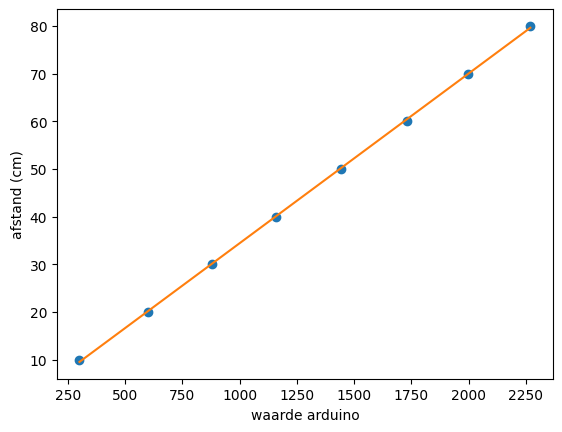

De kalibratieformule is: Afstand = 0.036 * waarde_arduino + -1.173


In [3]:
# verwerk hier jullie kalibratiemetingen 
from scipy.optimize import curve_fit

afstand_kalibratie=np.array([10,20, 30, 40, 50, 60, 70, 80]) #cm
waarde_arduino_kalibratie=np.array([301, 600, 880, 1160, 1441, 1730, 1997, 2270])
# Lineair verband

def kalibratie(x, a, b):
    return a*x + b

val, cov=curve_fit(kalibratie, waarde_arduino_kalibratie, afstand_kalibratie)

plt.figure()
plt.plot(waarde_arduino_kalibratie, afstand_kalibratie, 'o')
plt.plot(waarde_arduino_kalibratie, kalibratie(waarde_arduino_kalibratie, *val), label='fit: a=%5.3f, b=%5.3f' % tuple(val))
plt.xlabel('waarde arduino')
plt.ylabel('afstand (cm)')
plt.show()
print(f"De kalibratieformule is: Afstand = {val[0]:.3f} * waarde_arduino + {val[1]:.3f}")

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  40.50
1   0  30   0  20  40.80
2  40   0  30   0  40.05
3  30   0  20   0  41.00


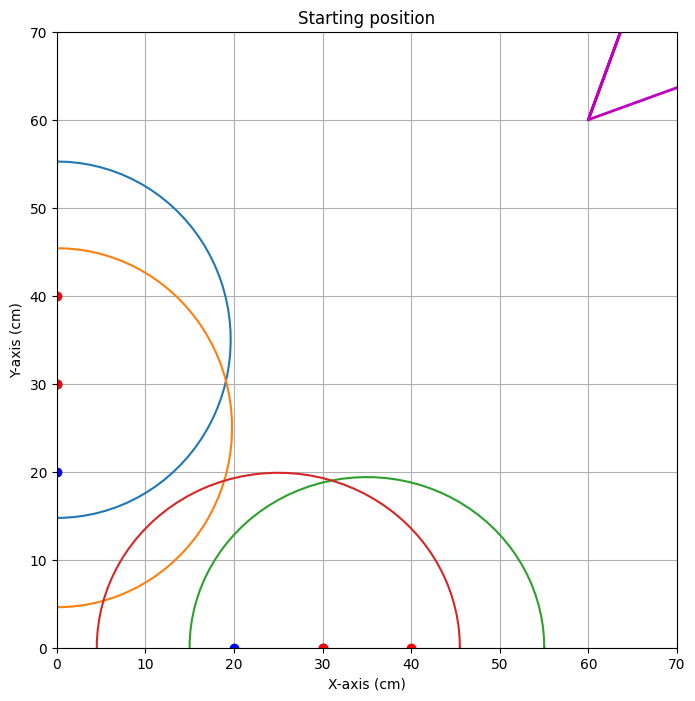


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.367


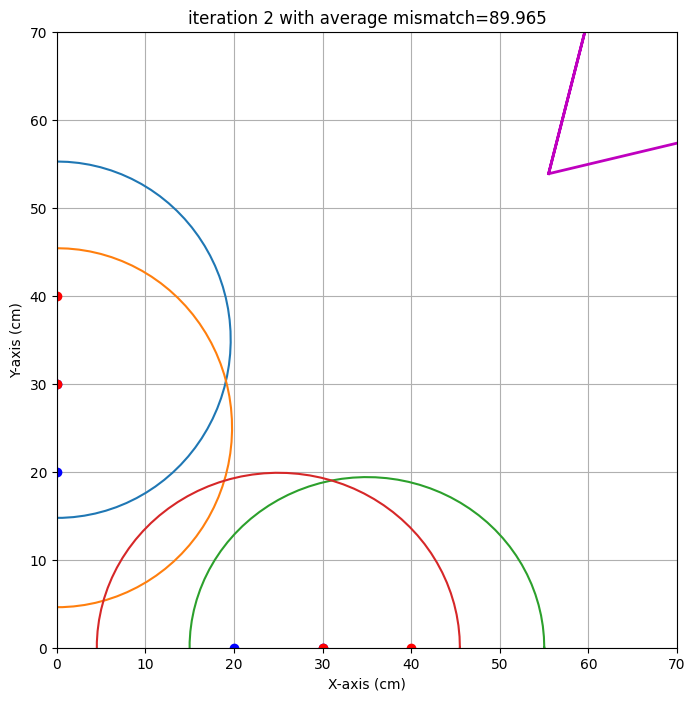

end iteration 2 with average mismatch=89.965


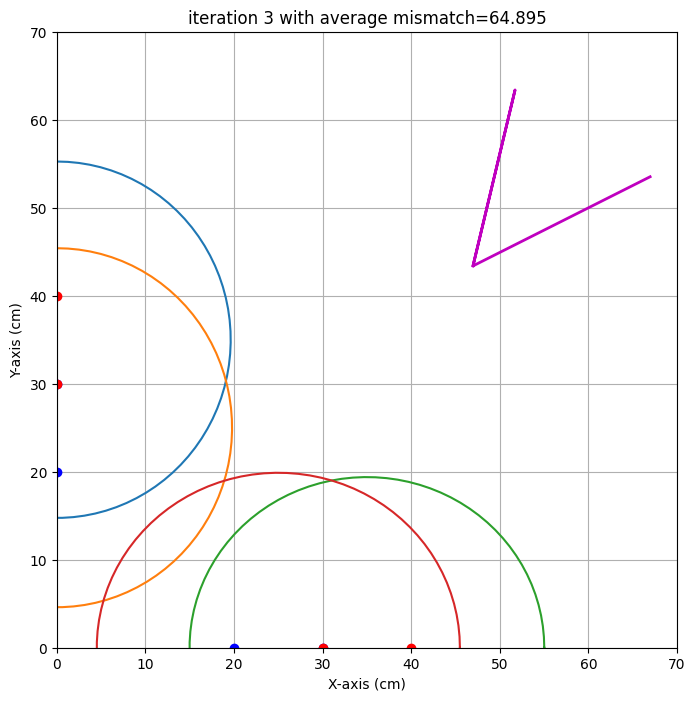

end iteration 3 with average mismatch=64.895


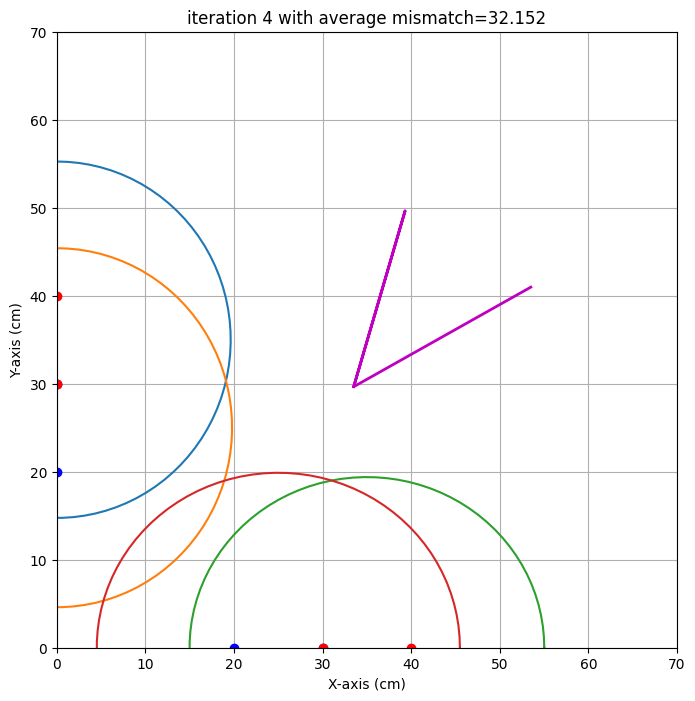

end iteration 4 with average mismatch=32.152


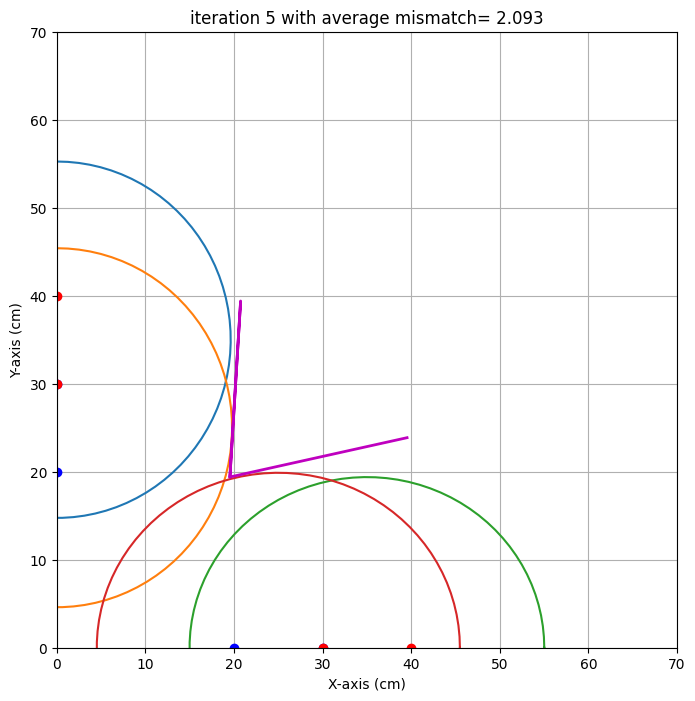

end iteration 5 with average mismatch= 2.093


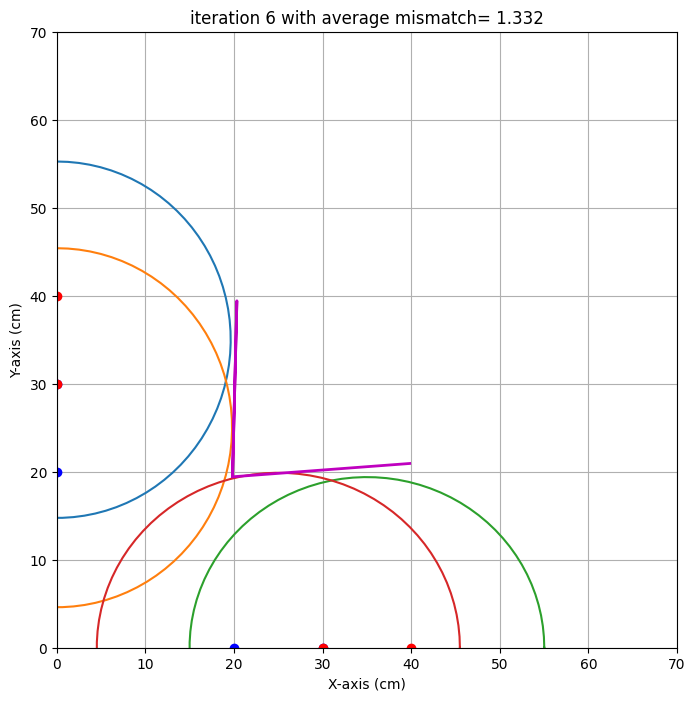

end iteration 6 with average mismatch= 1.332


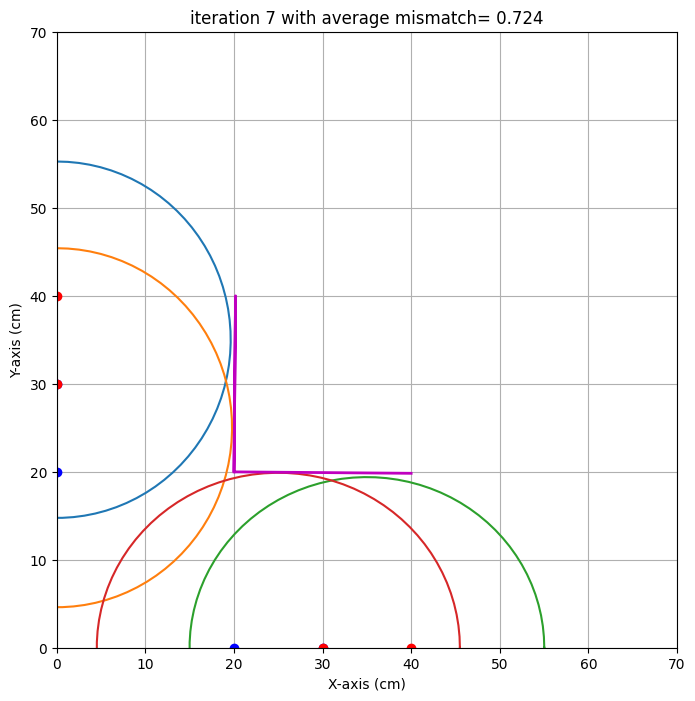

end iteration 7 with average mismatch= 0.724


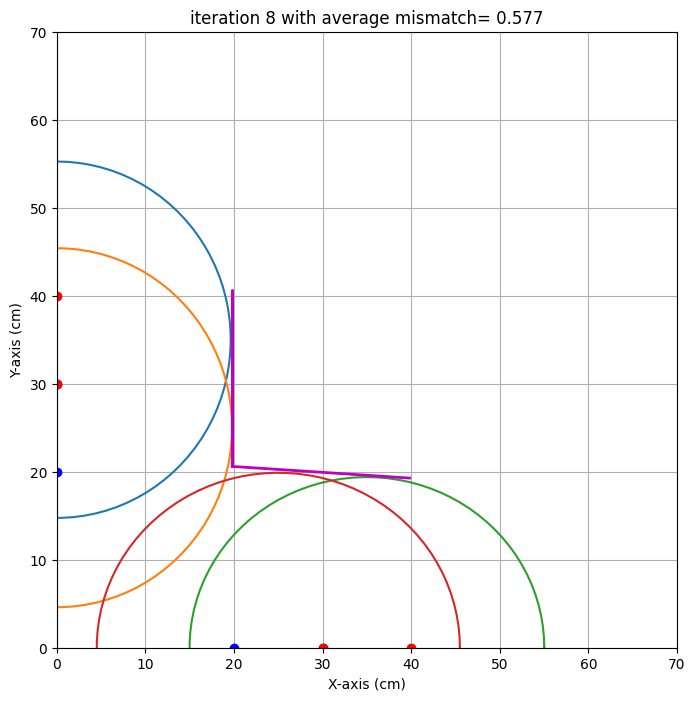

end iteration 8 with average mismatch= 0.577


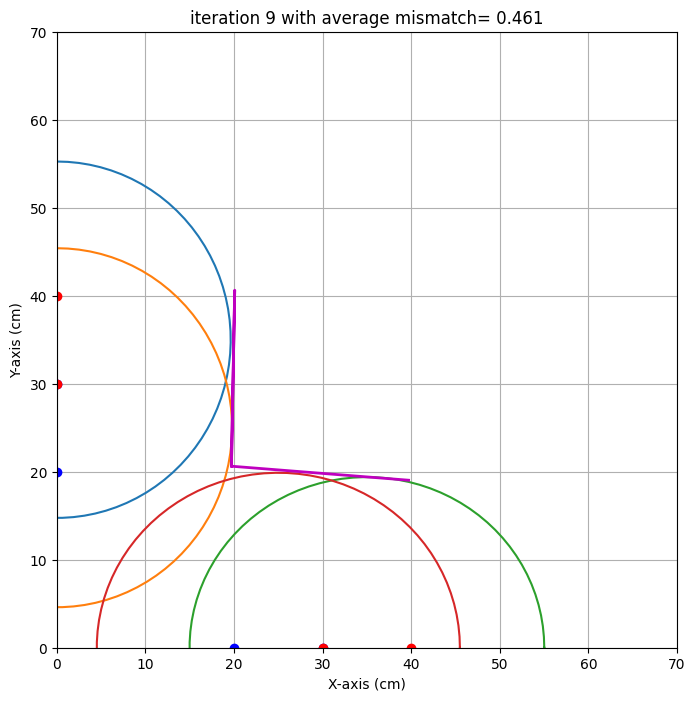

end iteration 9 with average mismatch= 0.461
end iteration 10 with average mismatch= 0.453


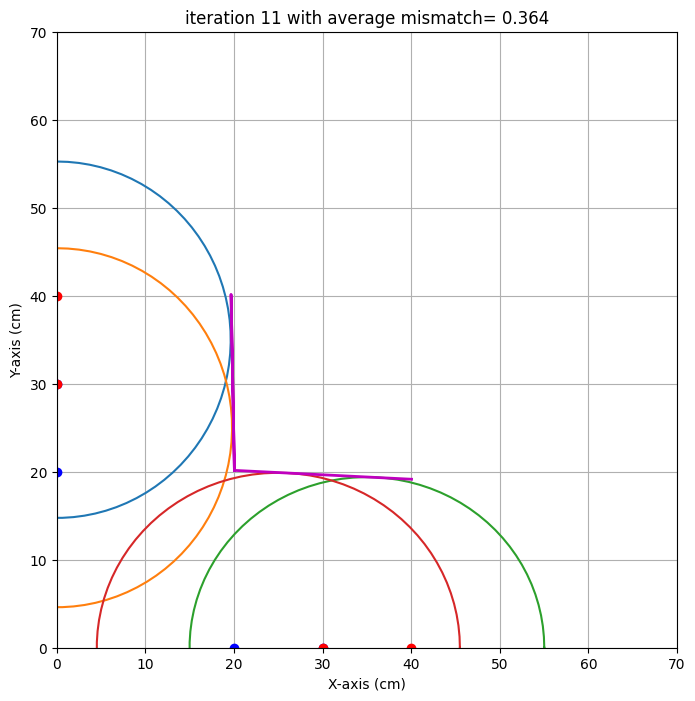

end iteration 11 with average mismatch= 0.364


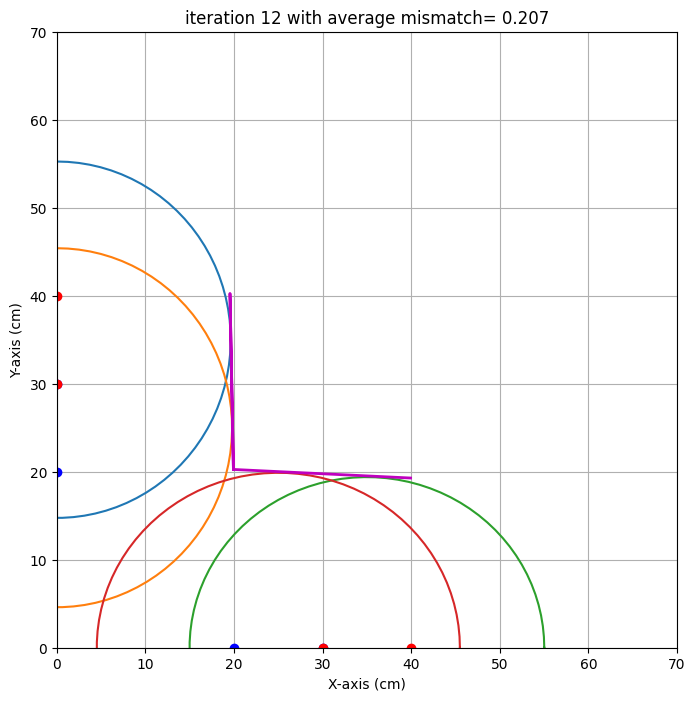

end iteration 12 with average mismatch= 0.207


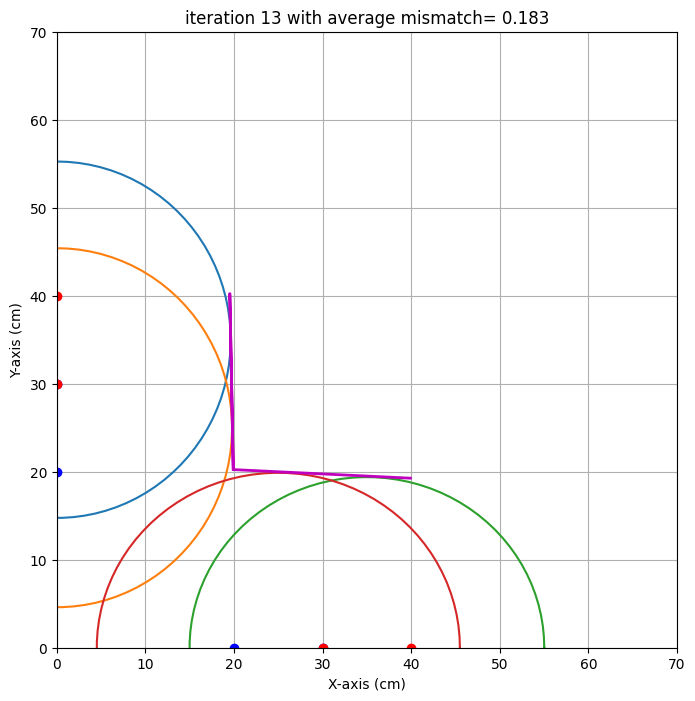

end iteration 13 with average mismatch= 0.183
end iteration 14 with average mismatch= 0.181
end iteration 15 with average mismatch= 0.181
end iteration 16 with average mismatch= 0.181
end iteration 17 with average mismatch= 0.181
end iteration 18 with average mismatch= 0.181
end iteration 19 with average mismatch= 0.181
end iteration 20 with average mismatch= 0.180
end iteration 21 with average mismatch= 0.180
end iteration 22 with average mismatch= 0.180
end iteration 23 with average mismatch= 0.180
end iteration 24 with average mismatch= 0.180
end iteration 25 with average mismatch= 0.180
end iteration 26 with average mismatch= 0.180
end iteration 27 with average mismatch= 0.180
end iteration 28 with average mismatch= 0.180
end iteration 29 with average mismatch= 0.180
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.180
###############################################################

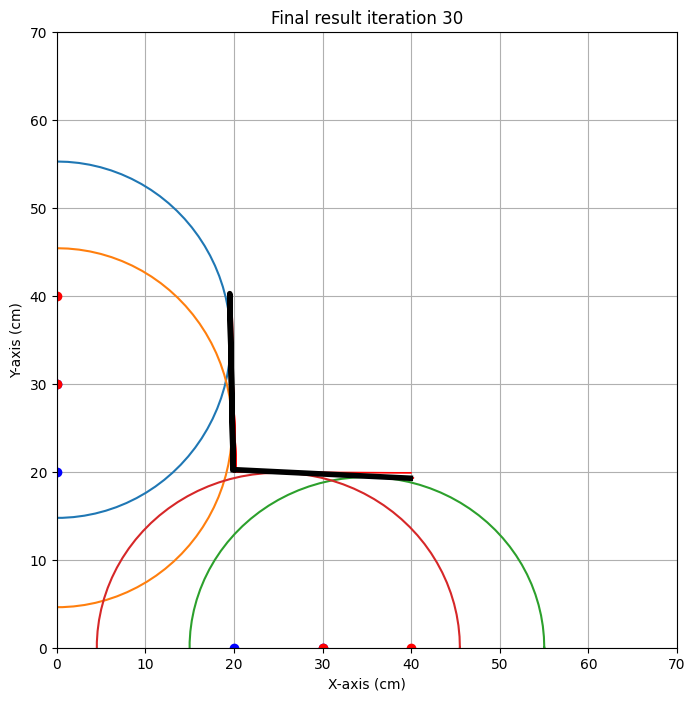

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.8],
    #[0,10,0,20,49.5],
    [40,0,30,0,40.05],
    [30,0,20,0,41.0],
    #[10,0,20,0,47],
    #[10,0,0,10,]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.9 cm met een standaardafwijking van 0.3 cm 
y0: 20.2 cm met een standaardafwijking van 0.3 cm 
alpha: -2.8 graden met een standaardafwijking van 2.6 graad 
beta: -1.1 graden met een standaardafwijking van 0.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Bob Villerius]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algorBob.jpeg" width="400">

#### algoritme [Adam Echant Hamdioui]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algorAdam1.jpeg" width="400">
<img src="algorAdam2.jpeg" width="400">

#### algoritme [Dexter Mourik]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algorDexter.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':29,  #zelf aanvullen,
           'y0':39,#zelf aanvullen,
           'alpha' :-11, #zelf aanvullen,
           'beta' : -19#zelf aanvullen},    
}       

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Bob Villerius' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[20,0,40,0,x],
   [0,50,0,70,70.2], 
   [0,45,0,65,67.12],
   [20,0,40,0, 76.95],
   [25,0,45,0, 75]
    ])
,
       'Adam Echant Hamdioui' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,0,50,x],
   [70,0,50,0,70],
   [0,50,0,30,72.6],
   #[50,0,30,0,x],
   [0,40,0,20, 77.34]
   #[0,40,0,20,x]
    ])}

## Opdracht 7: Evaluatie.

Bob Villerius
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  70  70.20
1   0  45   0  65  67.12
2  20   0  40   0  76.95
3  25   0  45   0  75.00


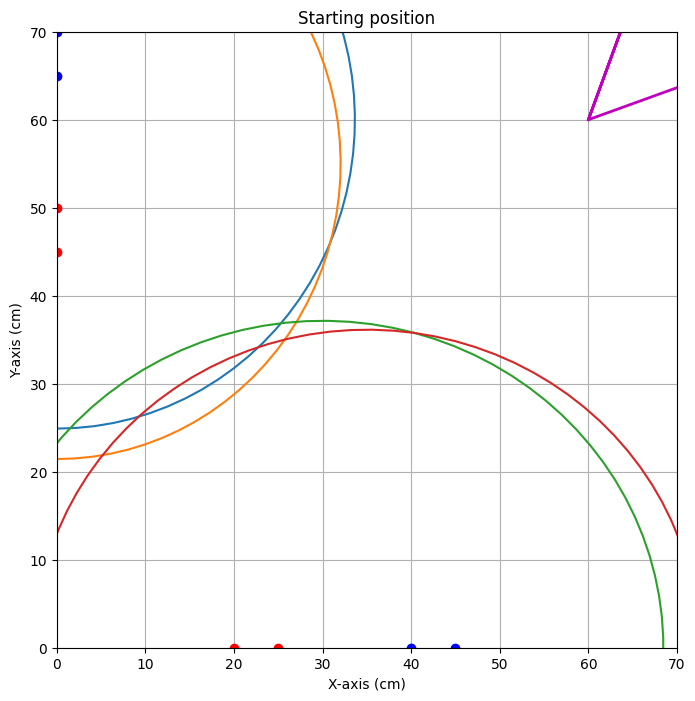


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.666


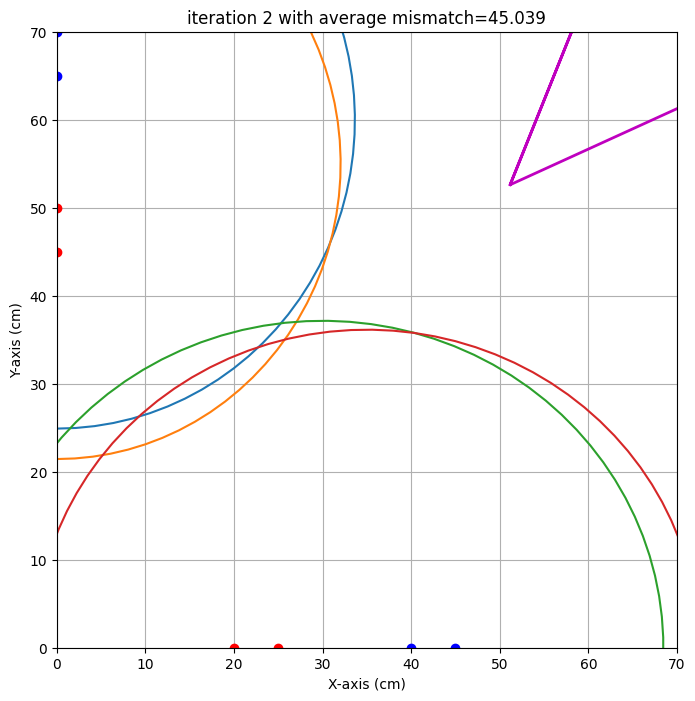

end iteration 2 with average mismatch=45.039


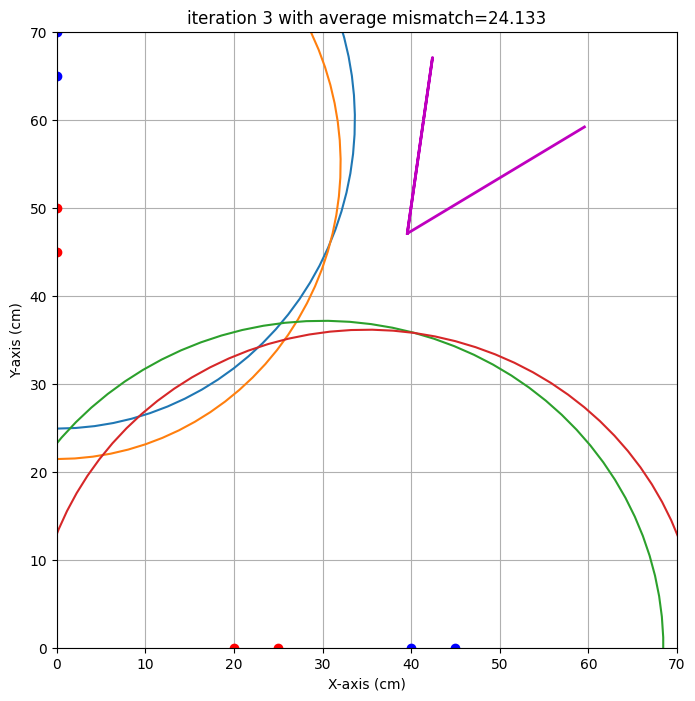

end iteration 3 with average mismatch=24.133


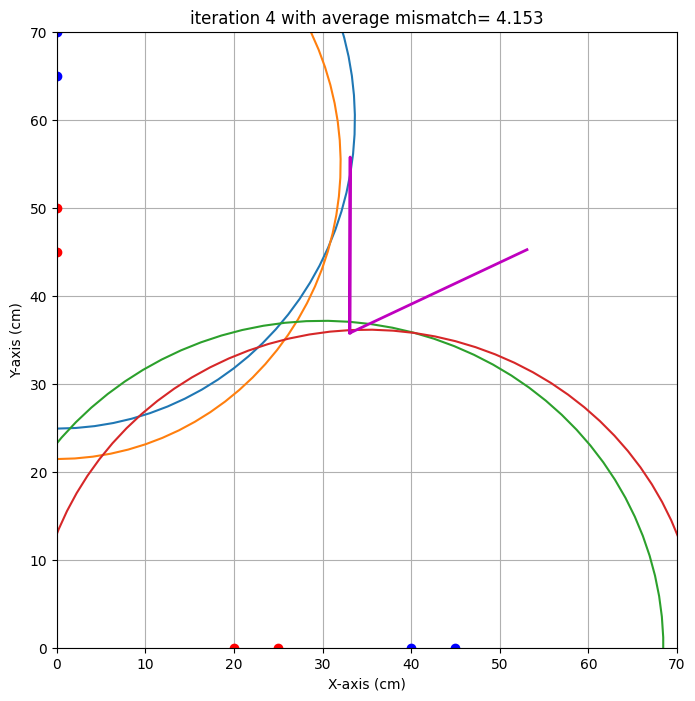

end iteration 4 with average mismatch= 4.153
end iteration 5 with average mismatch= 3.820


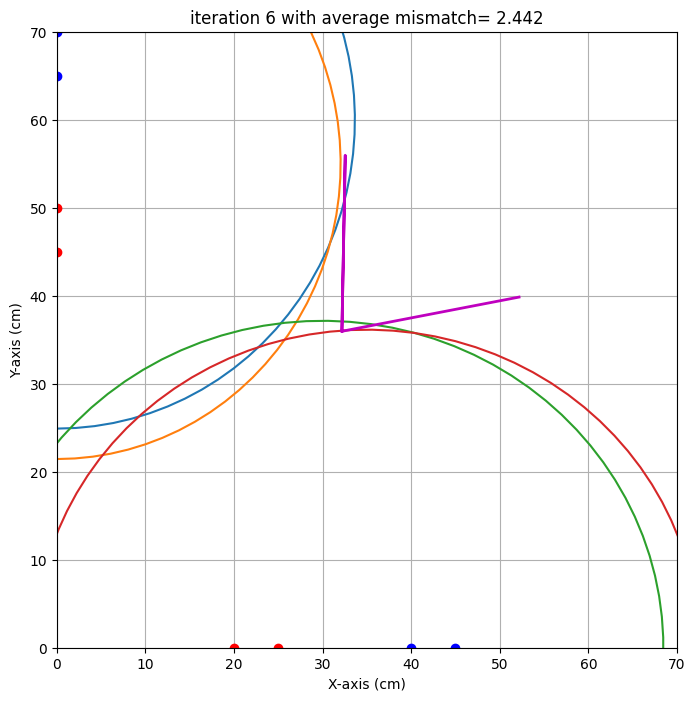

end iteration 6 with average mismatch= 2.442


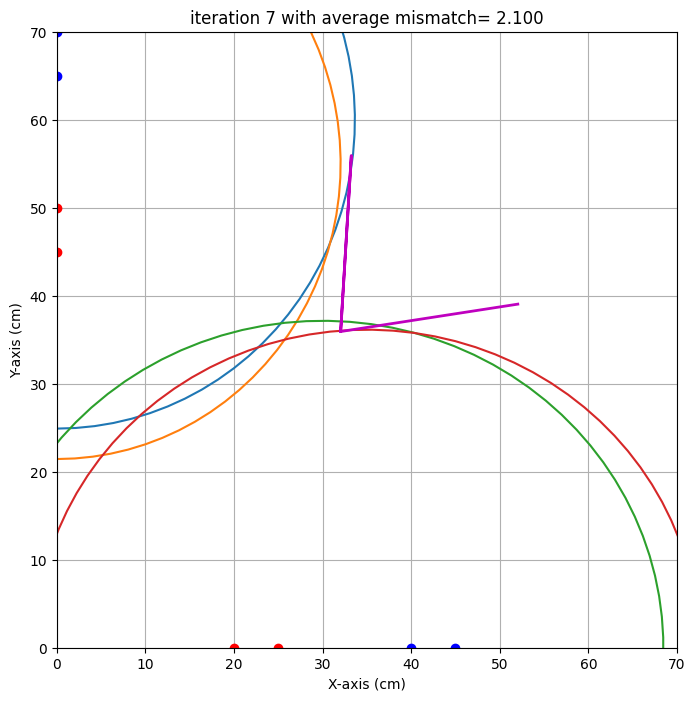

end iteration 7 with average mismatch= 2.100


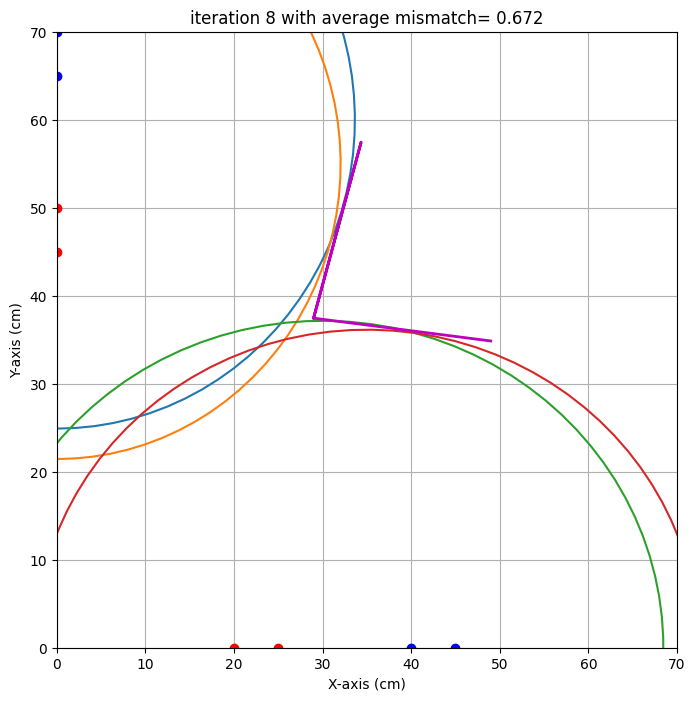

end iteration 8 with average mismatch= 0.672


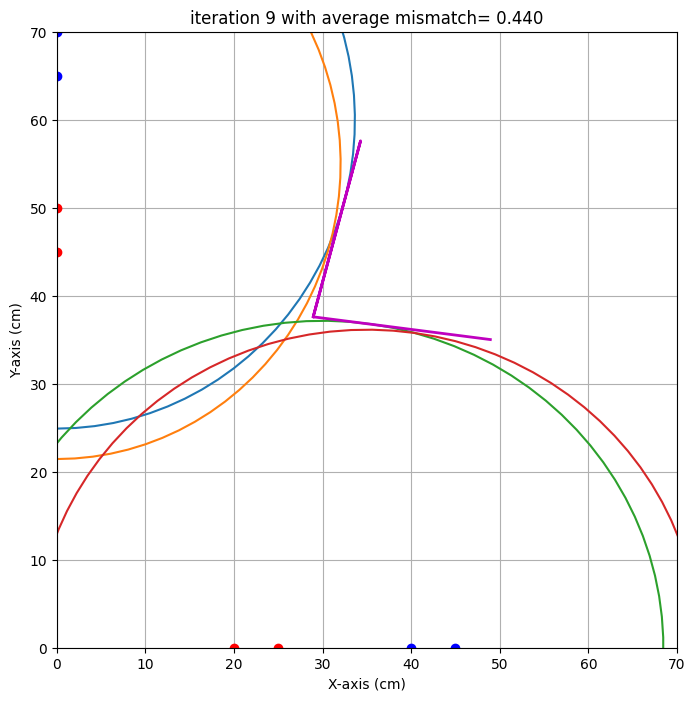

end iteration 9 with average mismatch= 0.440
end iteration 10 with average mismatch= 0.440
end iteration 11 with average mismatch= 0.440


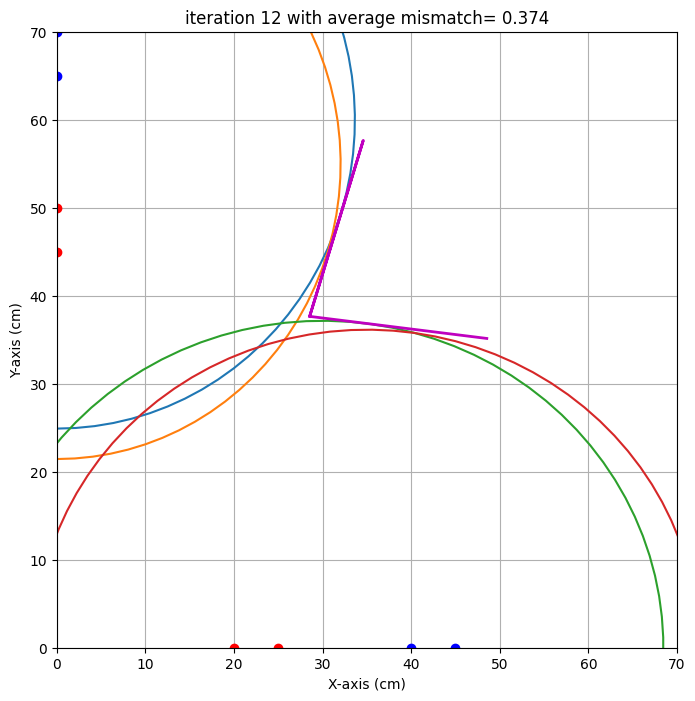

end iteration 12 with average mismatch= 0.374
end iteration 13 with average mismatch= 0.368


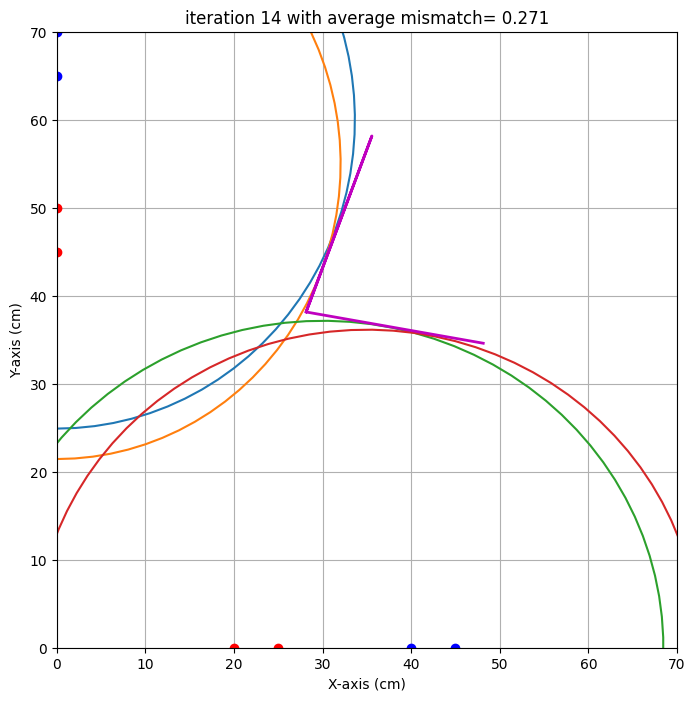

end iteration 14 with average mismatch= 0.271


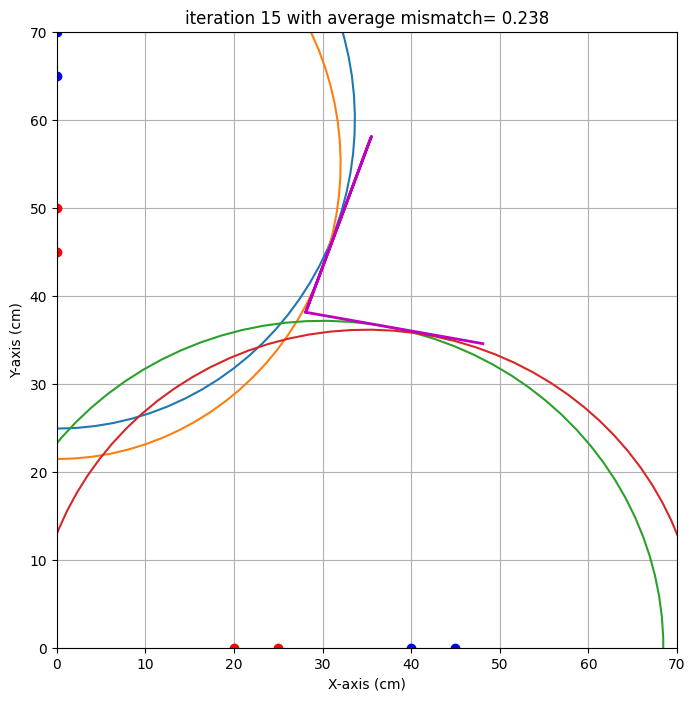

end iteration 15 with average mismatch= 0.238
end iteration 16 with average mismatch= 0.238
end iteration 17 with average mismatch= 0.238
end iteration 18 with average mismatch= 0.238
end iteration 19 with average mismatch= 0.238
end iteration 20 with average mismatch= 0.238


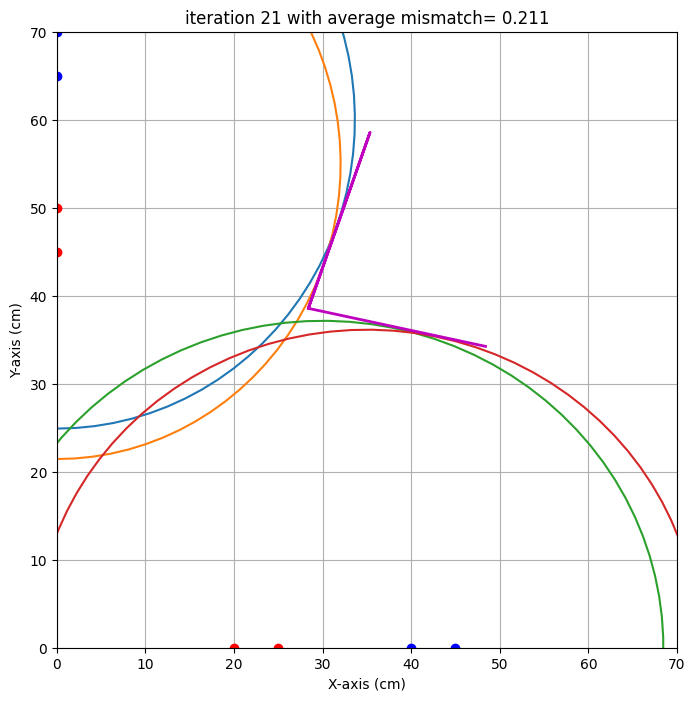

end iteration 21 with average mismatch= 0.211
end iteration 22 with average mismatch= 0.192
end iteration 23 with average mismatch= 0.173
end iteration 24 with average mismatch= 0.173
end iteration 25 with average mismatch= 0.173
end iteration 26 with average mismatch= 0.173
end iteration 27 with average mismatch= 0.173
end iteration 28 with average mismatch= 0.173
end iteration 29 with average mismatch= 0.173
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.173
###############################################################################
end of iteration  30
Best alpha= -12.35 with uncertainty=   7.10
Best beta =  18.88 with uncertainty=   3.20
Best x0   =  28.39 with uncertainty=   0.45
Best y0   =  38.49 with uncertainty=   1.13
###############################################################################


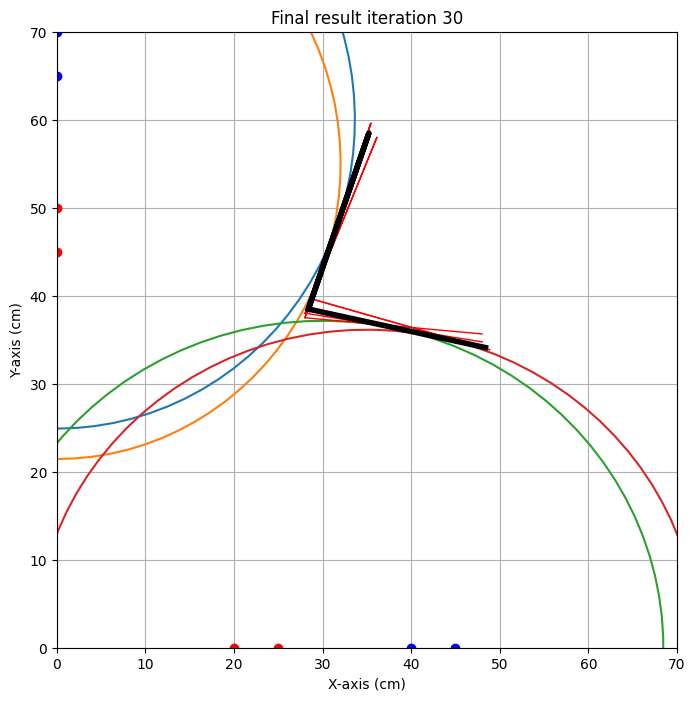

{'alpha': np.float64(-12.353517042713596), 'alpha_eps': np.float64(7.103086098583425), 'beta': np.float64(18.884507199223055), 'beta_eps': np.float64(3.1961865455720684), 'x0': np.float64(28.3850886723694), 'x0_eps': np.float64(0.4530766168247702), 'y0': np.float64(38.48546746774519), 'y0_eps': np.float64(1.127982432051276)}
Adam Echant Hamdioui
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  50   0  70.00
1   0  50   0  30  72.60
2   0  40   0  20  77.34


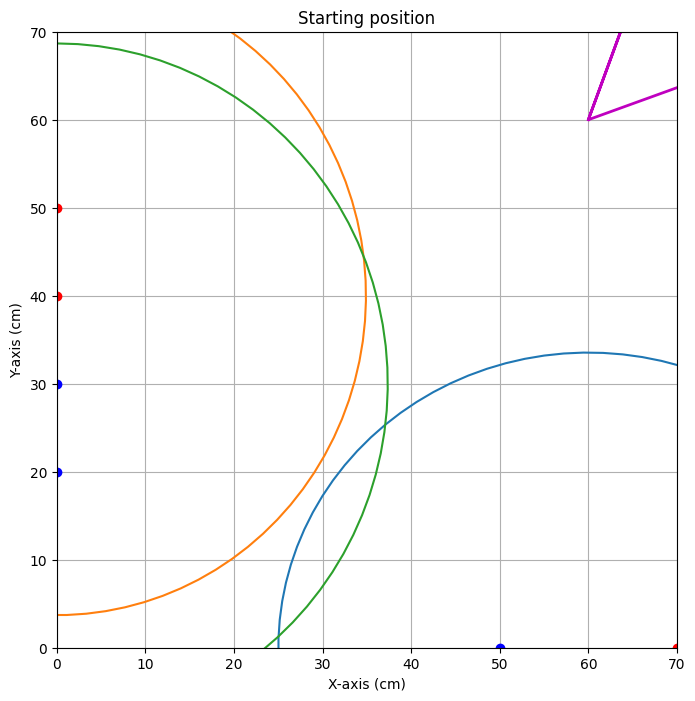


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.238


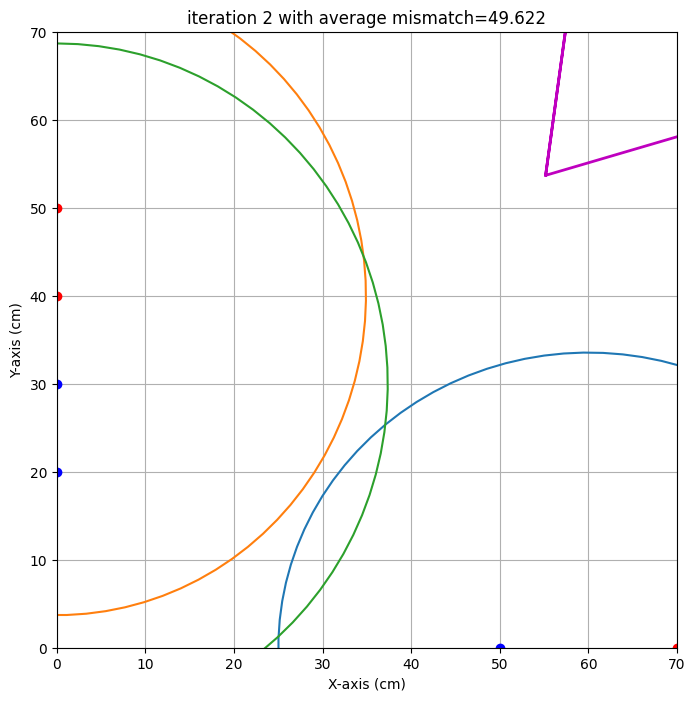

end iteration 2 with average mismatch=49.622


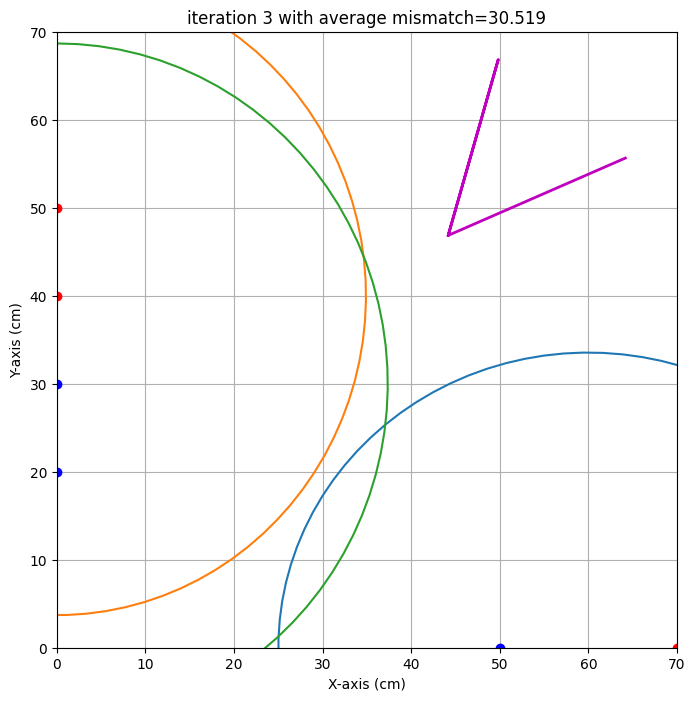

end iteration 3 with average mismatch=30.519


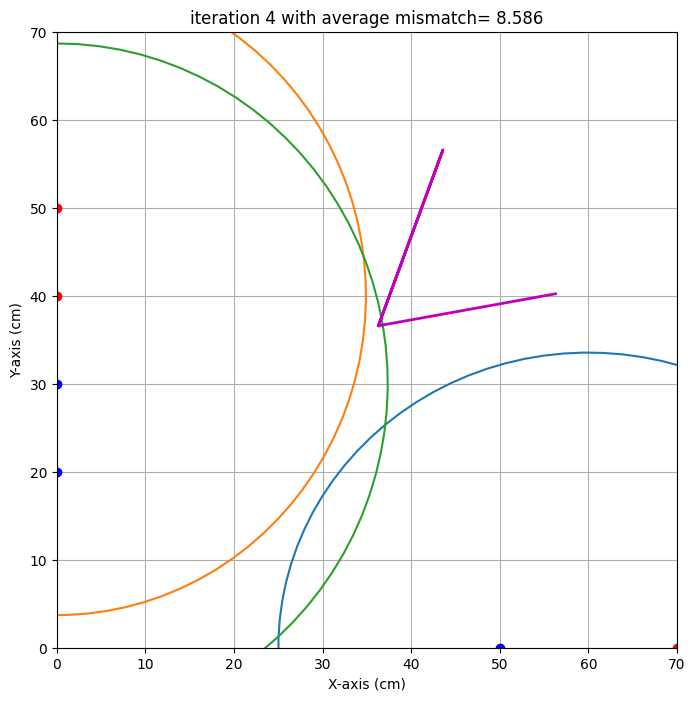

end iteration 4 with average mismatch= 8.586


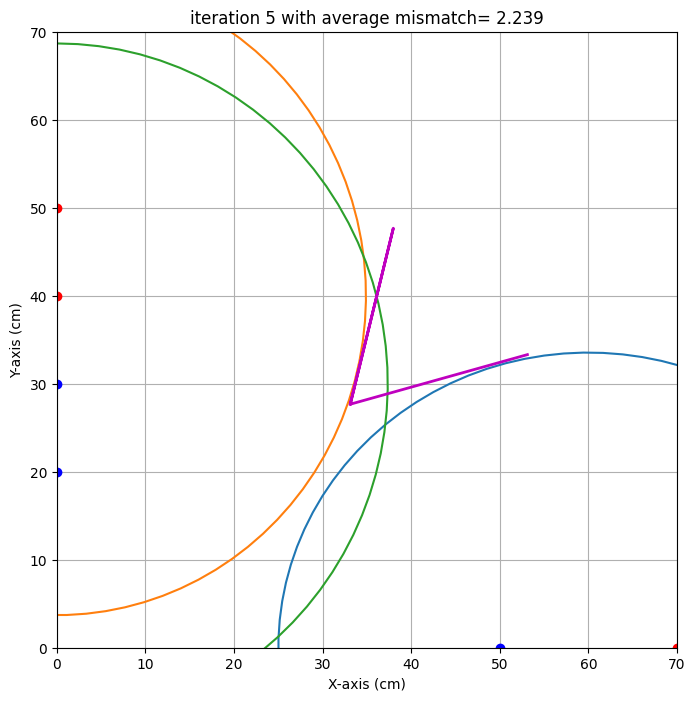

end iteration 5 with average mismatch= 2.239
end iteration 6 with average mismatch= 2.062
end iteration 7 with average mismatch= 1.990
end iteration 8 with average mismatch= 1.849


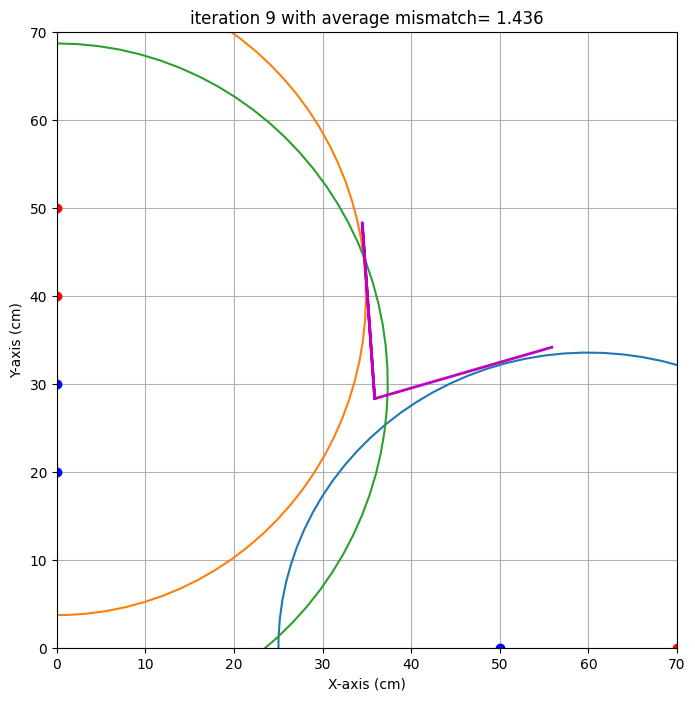

end iteration 9 with average mismatch= 1.436


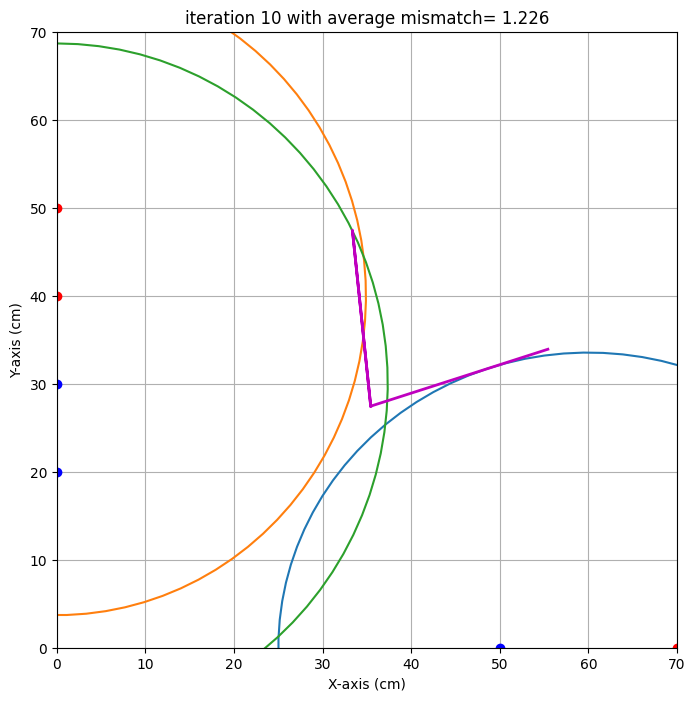

end iteration 10 with average mismatch= 1.226


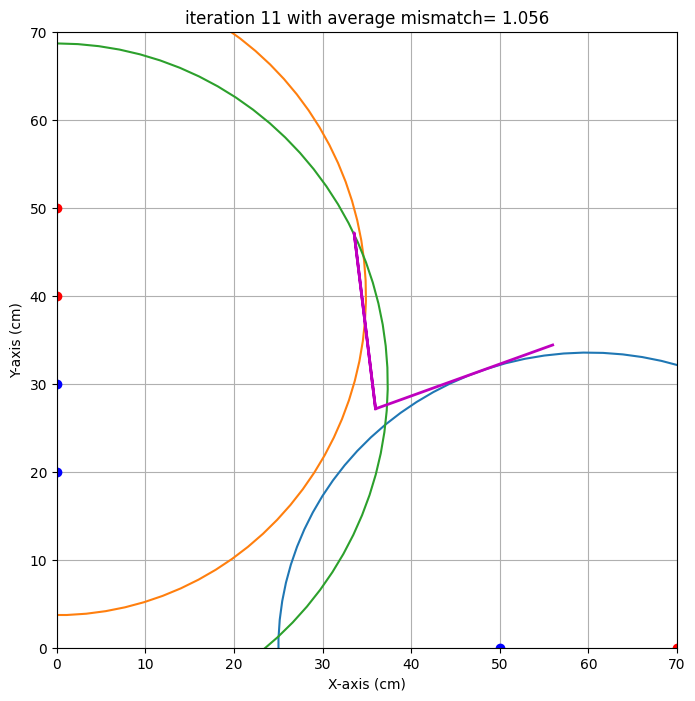

end iteration 11 with average mismatch= 1.056
end iteration 12 with average mismatch= 0.968


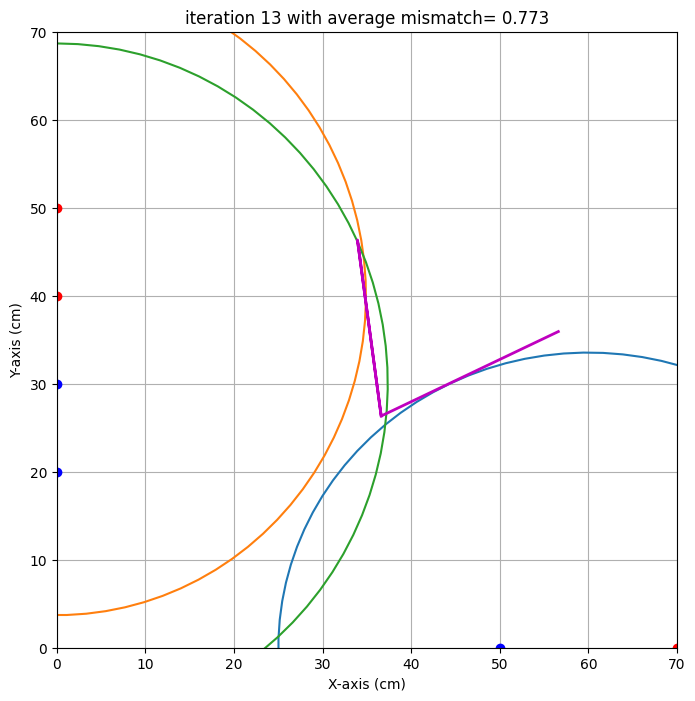

end iteration 13 with average mismatch= 0.773
end iteration 14 with average mismatch= 0.773
end iteration 15 with average mismatch= 0.764
end iteration 16 with average mismatch= 0.734
end iteration 17 with average mismatch= 0.733
end iteration 18 with average mismatch= 0.733
end iteration 19 with average mismatch= 0.733
end iteration 20 with average mismatch= 0.660
end iteration 21 with average mismatch= 0.660
end iteration 22 with average mismatch= 0.660
end iteration 23 with average mismatch= 0.660
end iteration 24 with average mismatch= 0.660
end iteration 25 with average mismatch= 0.660
end iteration 26 with average mismatch= 0.660
end iteration 27 with average mismatch= 0.660
end iteration 28 with average mismatch= 0.654
end iteration 29 with average mismatch= 0.654
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.654
###############################################################

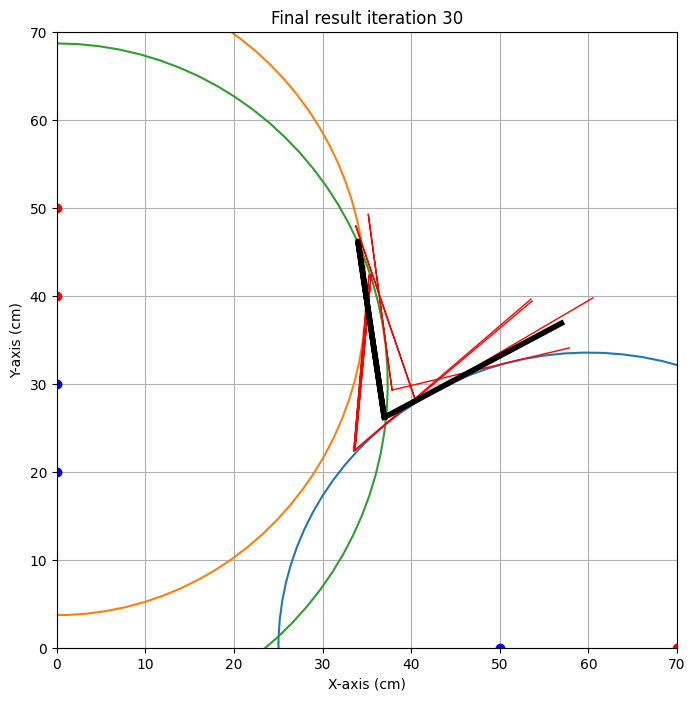

{'alpha': np.float64(28.14458684704442), 'alpha_eps': np.float64(14.694262926593067), 'beta': np.float64(-8.460842894406438), 'beta_eps': np.float64(13.727198840787077), 'x0': np.float64(36.95991849558986), 'x0_eps': np.float64(3.5737752745865734), 'y0': np.float64(26.173082219413303), 'y0_eps': np.float64(3.80723372670888)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bob Villerius 
x0 target is : 29.0. Gevonden waarde: 28.4 cm met een standaardafwijking van 0.5 cm 
y0 target is : 39.0. Gevonden waarde: 38.5 cm met een standaardafwijking van 1.1 cm 
alpha target is : -11.0. Gevonden waarde: -12.4 graden met een standaardafwijking van 7.1 graad 
beta target is : -19.0. Gevonden waarde: 18.9 graden met een standaardafwijking van 3.2 graad 

Adam Echant Hamdioui 
x0 target is : 29.0. Gevonden waarde: 37.0 cm met een standaardafwijking van 3.6 cm 
y0 target is : 39.0. Gevonden waarde: 26.2 cm met een standaardafwijking van 3.8 cm 
alpha target is : -11.0. Gevonden waarde: 28.1 graden met een standaardafwijking van 14.7 graad 
beta target is : -19.0. Gevonden waarde: -8.5 graden met een standaardafwijking van 13.7 graad 



## Opdracht 8: Iteratie1+. 14:48.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Algorfinal.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  40   0  107
1  15   0  35   0  115
2   0  50   0  70   90
3   0  45   0  65   89


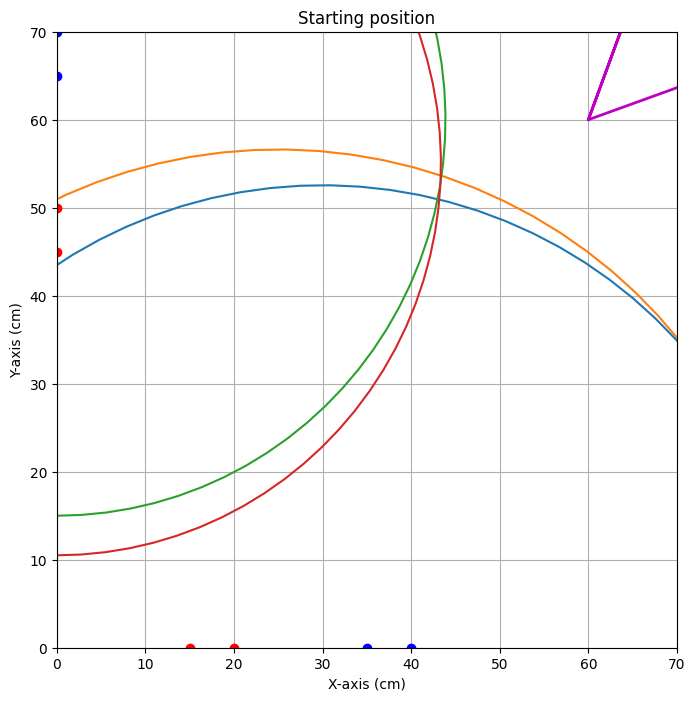


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.813


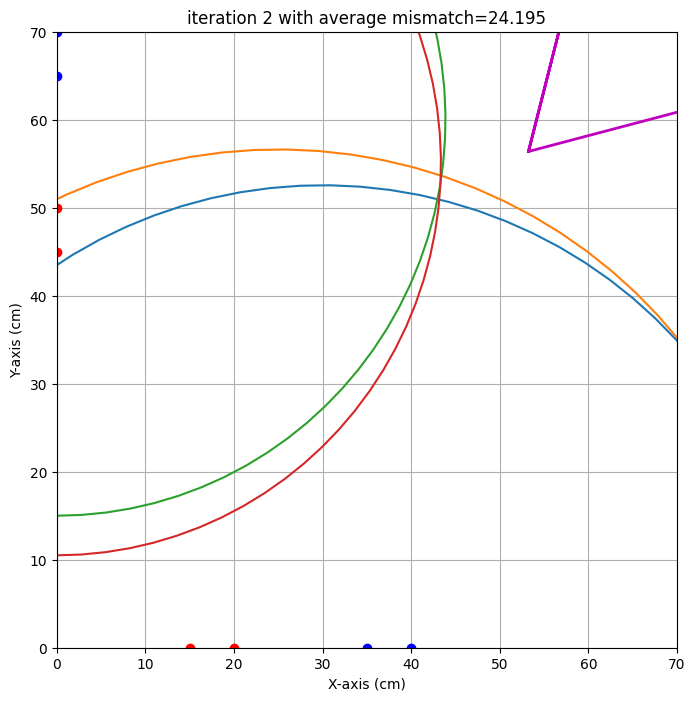

end iteration 2 with average mismatch=24.195


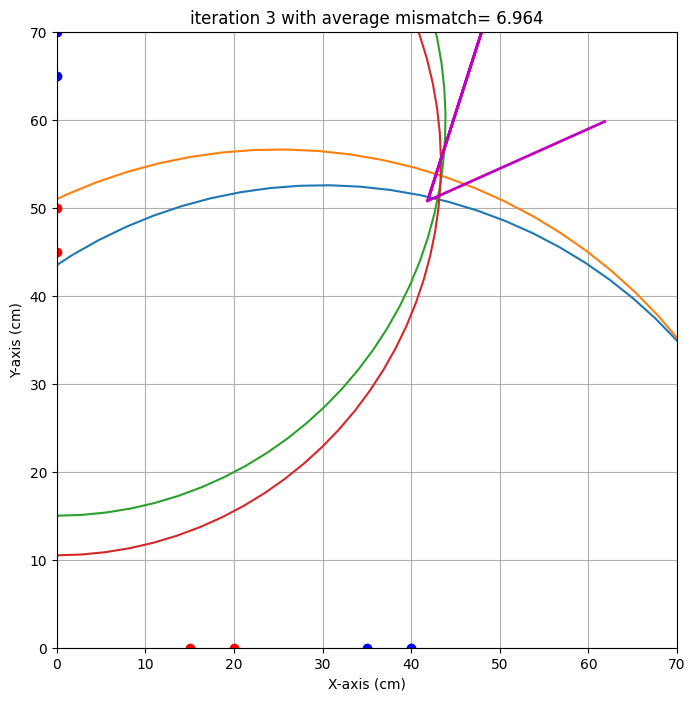

end iteration 3 with average mismatch= 6.964


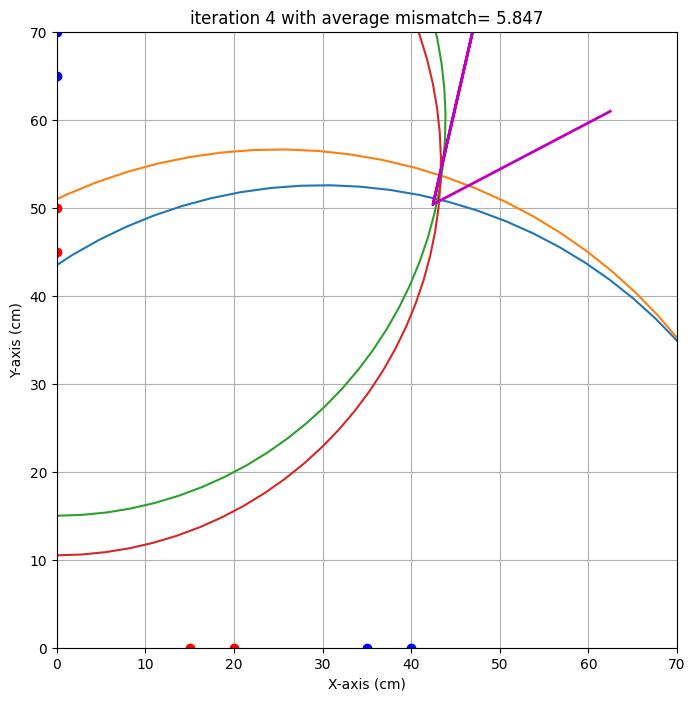

end iteration 4 with average mismatch= 5.847


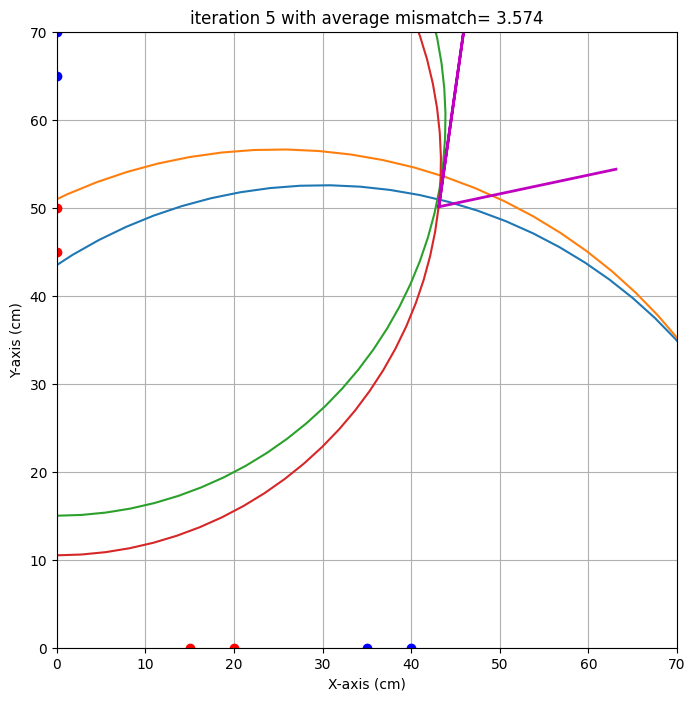

end iteration 5 with average mismatch= 3.574


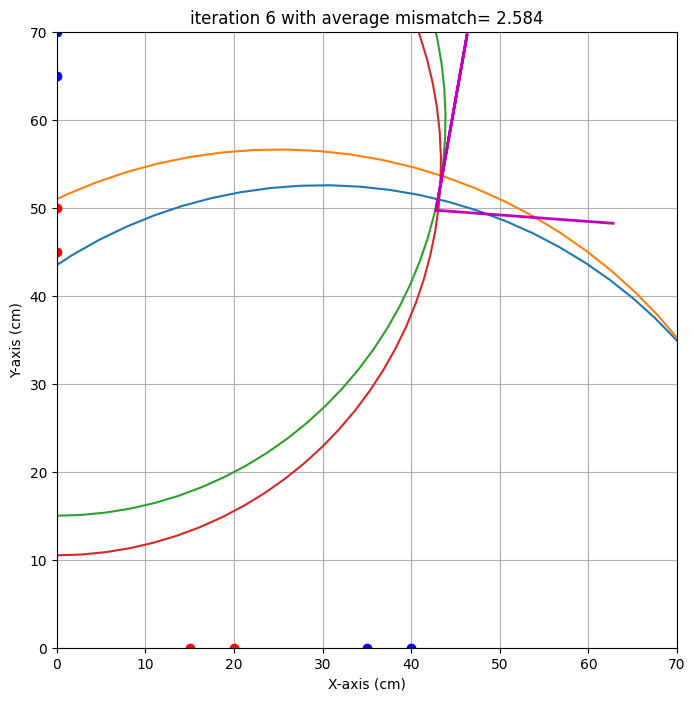

end iteration 6 with average mismatch= 2.584


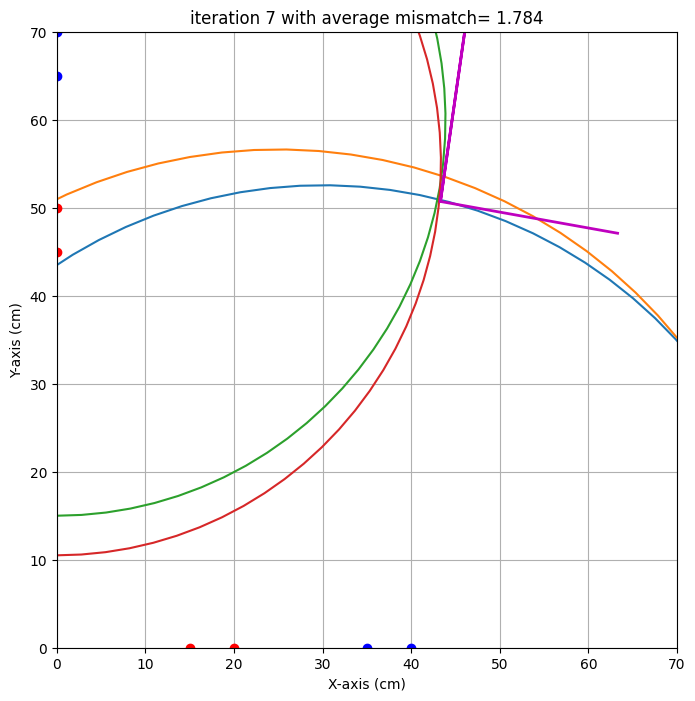

end iteration 7 with average mismatch= 1.784


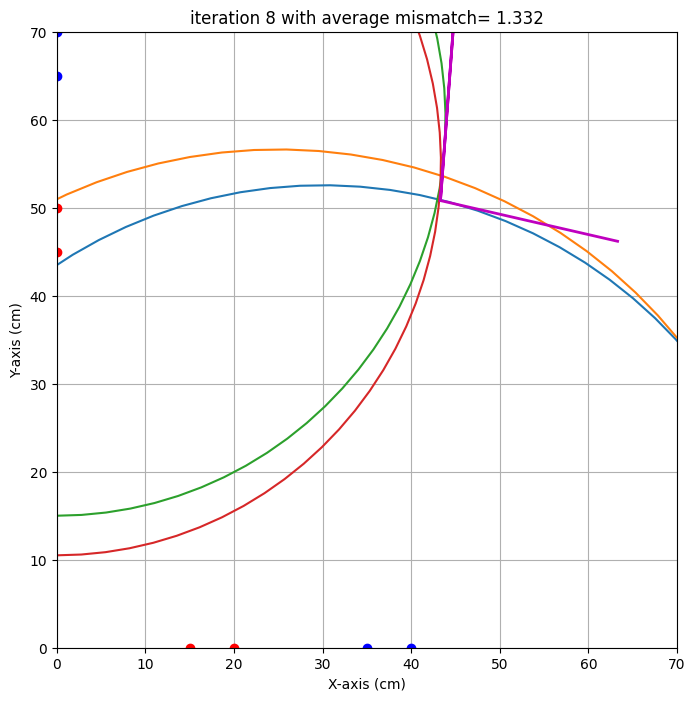

end iteration 8 with average mismatch= 1.332
end iteration 9 with average mismatch= 1.270
end iteration 10 with average mismatch= 1.231
end iteration 11 with average mismatch= 1.218
end iteration 12 with average mismatch= 1.217
end iteration 13 with average mismatch= 1.215
end iteration 14 with average mismatch= 1.214
end iteration 15 with average mismatch= 1.144
end iteration 16 with average mismatch= 1.129
end iteration 17 with average mismatch= 1.128
end iteration 18 with average mismatch= 1.128
end iteration 19 with average mismatch= 1.128
end iteration 20 with average mismatch= 1.128
end iteration 21 with average mismatch= 1.128
end iteration 22 with average mismatch= 1.128
end iteration 23 with average mismatch= 1.128
end iteration 24 with average mismatch= 1.128
end iteration 25 with average mismatch= 1.128
end iteration 26 with average mismatch= 1.128
end iteration 27 with average mismatch= 1.118
end iteration 28 with average mismatch= 1.109
end iteration 29 with average mismat

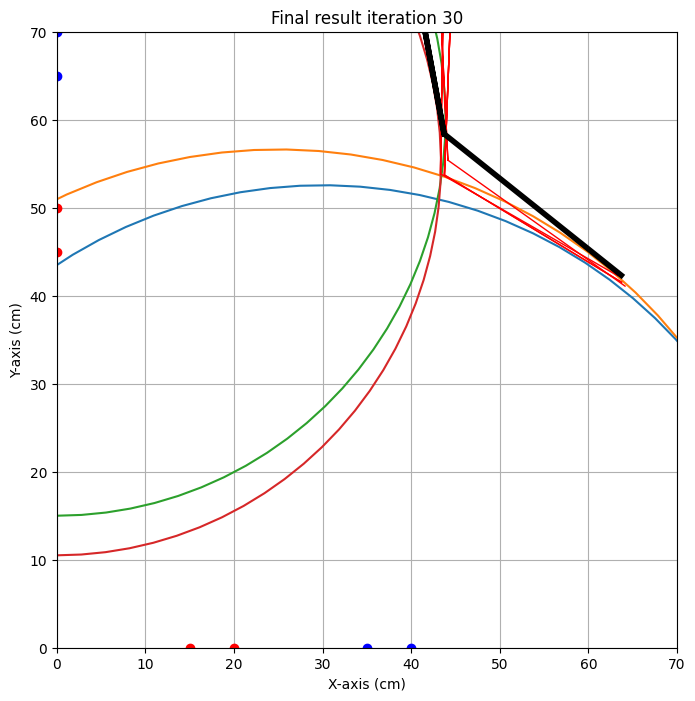

{'alpha': np.float64(-38.771808546064946), 'alpha_eps': np.float64(8.712274685909371), 'beta': np.float64(-10.485409138861627), 'beta_eps': np.float64(12.68893521716848), 'x0': np.float64(43.71789453520299), 'x0_eps': np.float64(0.4250589943590839), 'y0': np.float64(58.38842695136252), 'y0_eps': np.float64(4.662656849275464)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  70   0  83.50
1  45   0  65   0  81.90
2   0  50   0  70  72.50
3   0  45   0  65  70.75
4  35   0  55   0  77.70
5  40   0  60   0  80.20
6  30   0  50   0  76.26
7   0  35   0  55  66.72
8   0  40   0  60  68.52
9   0  30   0  50  67.77


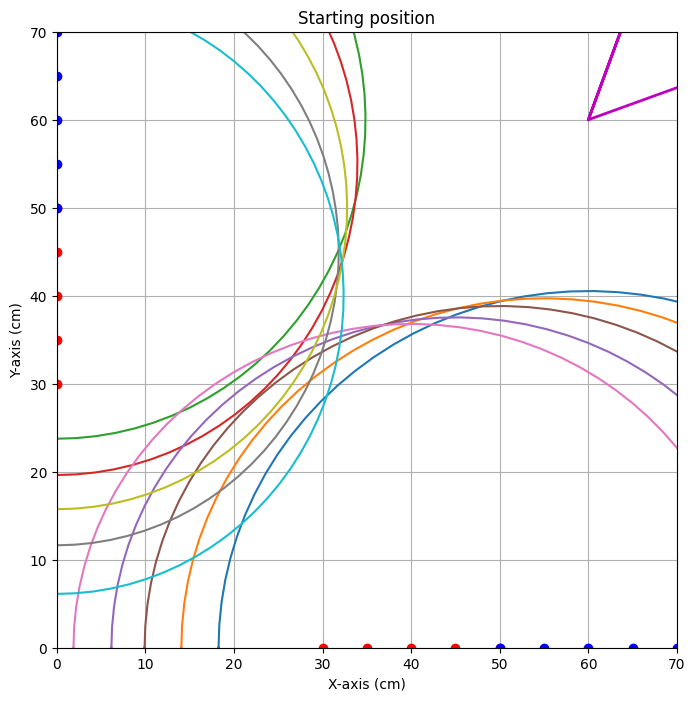


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.460


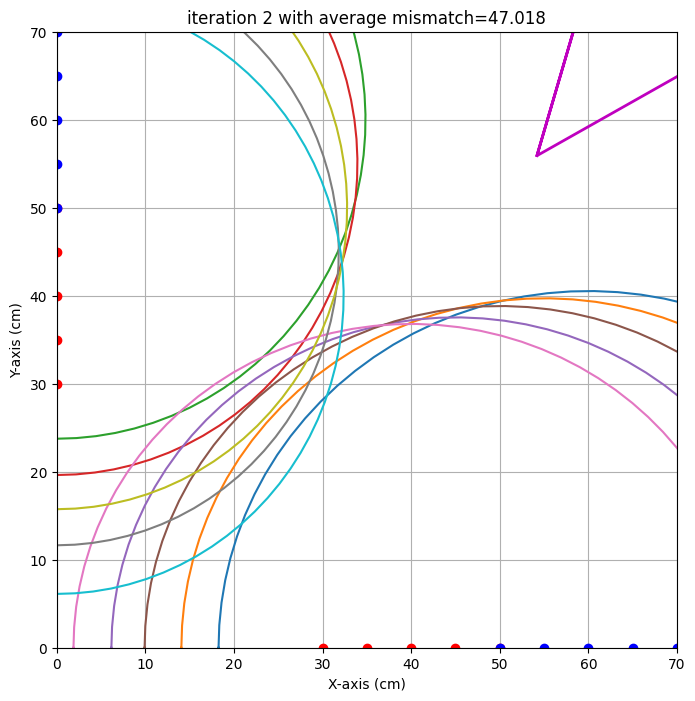

end iteration 2 with average mismatch=47.018


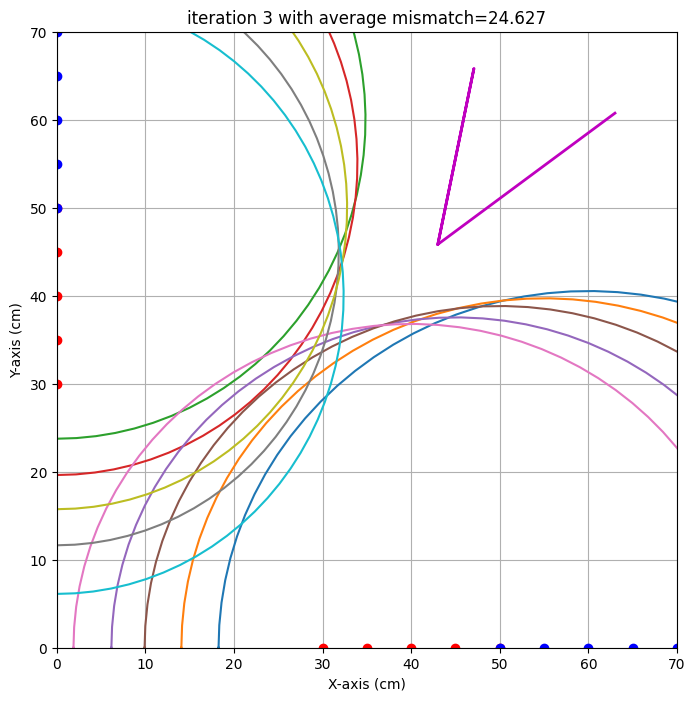

end iteration 3 with average mismatch=24.627


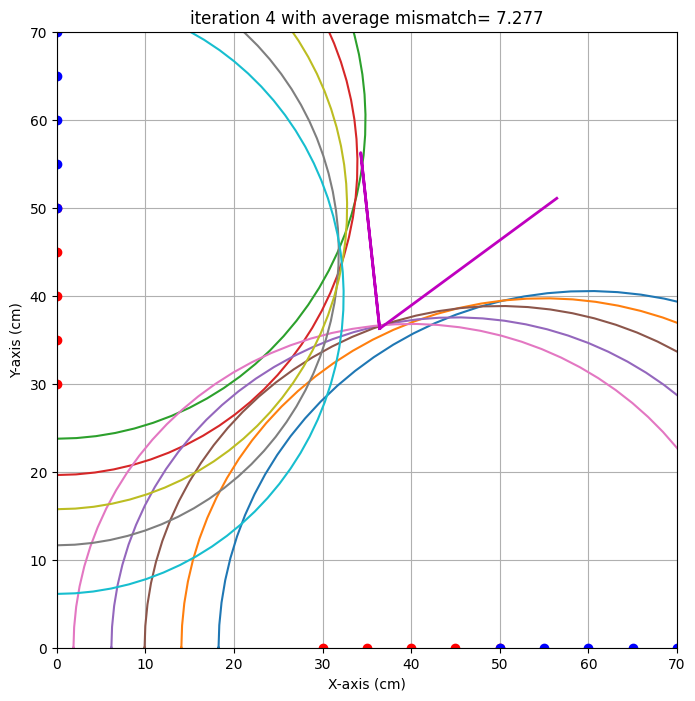

end iteration 4 with average mismatch= 7.277


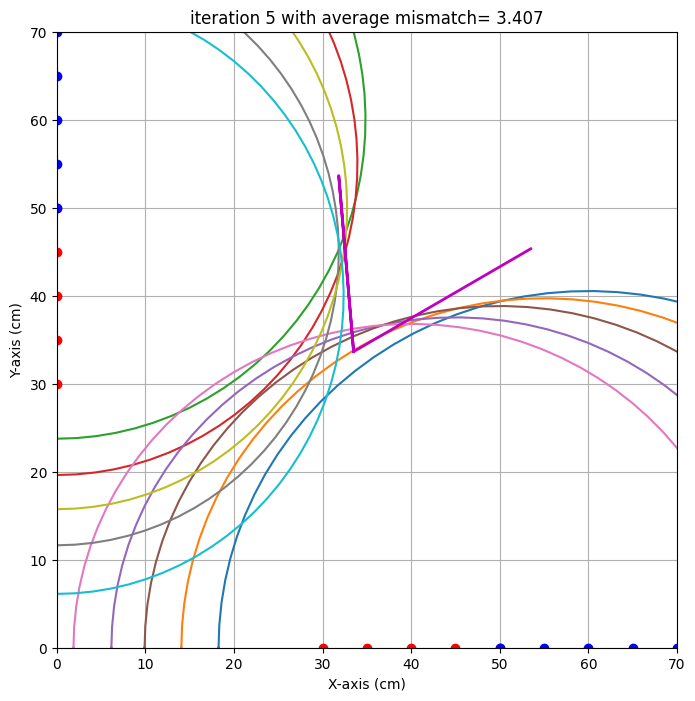

end iteration 5 with average mismatch= 3.407


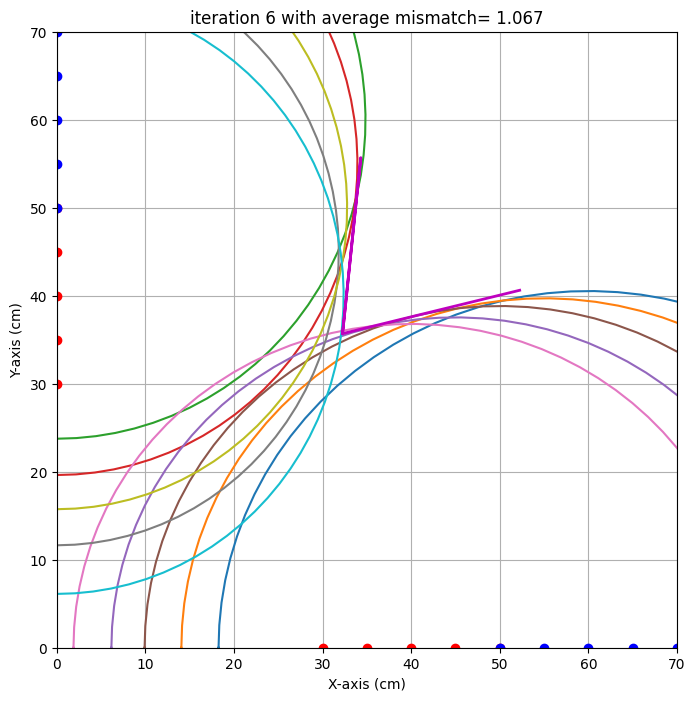

end iteration 6 with average mismatch= 1.067


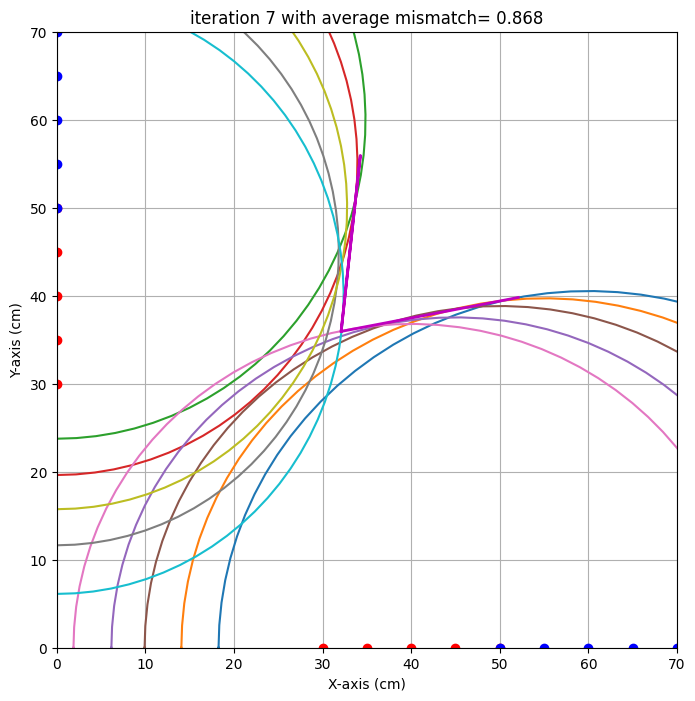

end iteration 7 with average mismatch= 0.868
end iteration 8 with average mismatch= 0.830
end iteration 9 with average mismatch= 0.787
end iteration 10 with average mismatch= 0.775
end iteration 11 with average mismatch= 0.768
end iteration 12 with average mismatch= 0.768
end iteration 13 with average mismatch= 0.768
end iteration 14 with average mismatch= 0.768
end iteration 15 with average mismatch= 0.768
end iteration 16 with average mismatch= 0.768
end iteration 17 with average mismatch= 0.768
end iteration 18 with average mismatch= 0.768
end iteration 19 with average mismatch= 0.768
end iteration 20 with average mismatch= 0.736
end iteration 21 with average mismatch= 0.719
end iteration 22 with average mismatch= 0.711
end iteration 23 with average mismatch= 0.707
end iteration 24 with average mismatch= 0.707
end iteration 25 with average mismatch= 0.707
end iteration 26 with average mismatch= 0.707
end iteration 27 with average mismatch= 0.707
end iteration 28 with average mismatc

KeyboardInterrupt: 

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':33.5,#zelf aanvullen,
                    'y0':28,#zelf aanvullen,
                    'alpha' :65, #zelf aanvullen,
                    'beta' : -51#zelf aanvullen}, 
},
           'locatie 2':{'x0':31, #zelf aanvullen,
                    'y0':35, #zelf aanvullen,
                    'alpha' :12, #zelf aanvullen,
                    'beta' :10 #zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    #[50,0,70,0,x],
    #[35,0,55,0,x]
    [20,0,40,0,107],
    #[25,0,45,0,x],
    [15,0,35,0,115],
    #[0,20,0,40,x],
    [0,50,0,70,90],
    [0,45,0,65,89]
    ])
    ,
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    [50,0,70,0,83.5],
    [45,0,65,0,81.9],
    #[0,20,0,40,x],
    [0,50,0,70,72.5],
    [0,45,0,65,70.75],
    [35,0,55,0,77.7],
    [40,0,60,0,80.2],
    [30,0,50,0, 76.26],
    [0,35,0,55,66.72],
    [0,40,0,60,68.52],
    [0,30,0,50,67.77]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
#[20,0,40,0,x]
                    #[50,0,70,0,127],
                    #[45,0,65,0,123],
                    #[35,0,55,0,117.81],
    #                [40,0,60,0,119],
     #               [30,0,50,0,114.6],
      #              #[0,20,0,40,x],
       #             [0,50,0,70,48],
        #            [0,45,0,65,51],
         #           [0,35,0,55,58],
          #          [0,40,0,60,55],
           #         [0,30,0,50,61]

IndentationError: unexpected indent (1409365619.py, line 2)

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  45   0  65   0  122.63
1  35   0  55   0  117.60
2  40   0  60   0  119.50
3  30   0  50   0  115.14
4   0  50   0  70   48.00
5   0  45   0  65   50.02
6   0  35   0  55   57.43
7   0  40   0  60   54.79
8   0  30   0  50   61.03


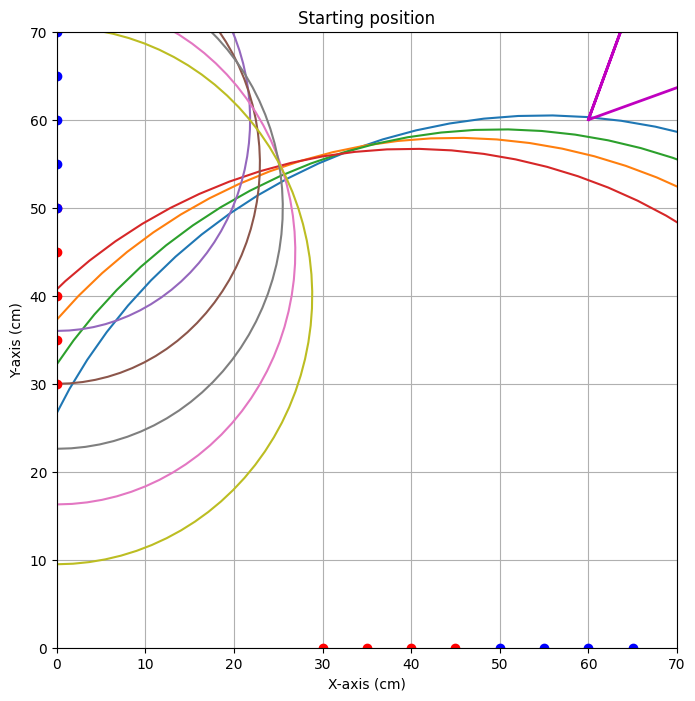


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.696


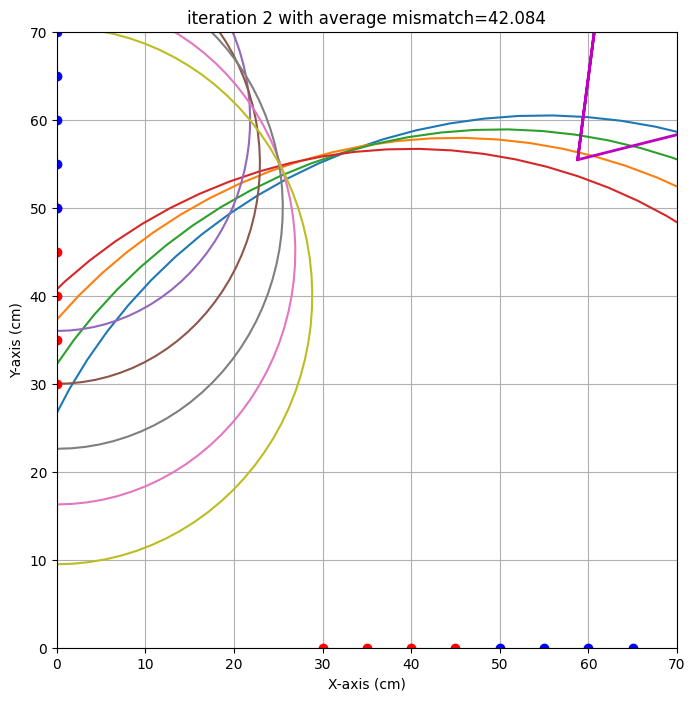

end iteration 2 with average mismatch=42.084


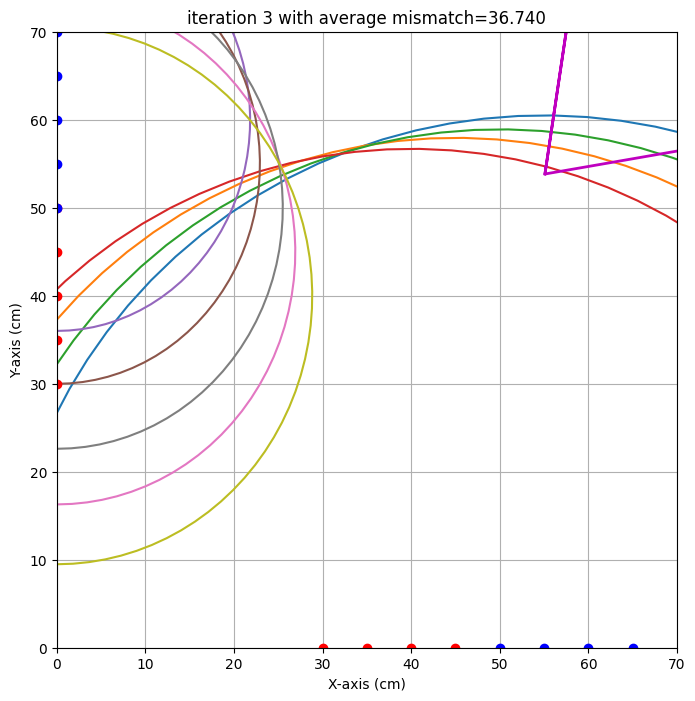

end iteration 3 with average mismatch=36.740


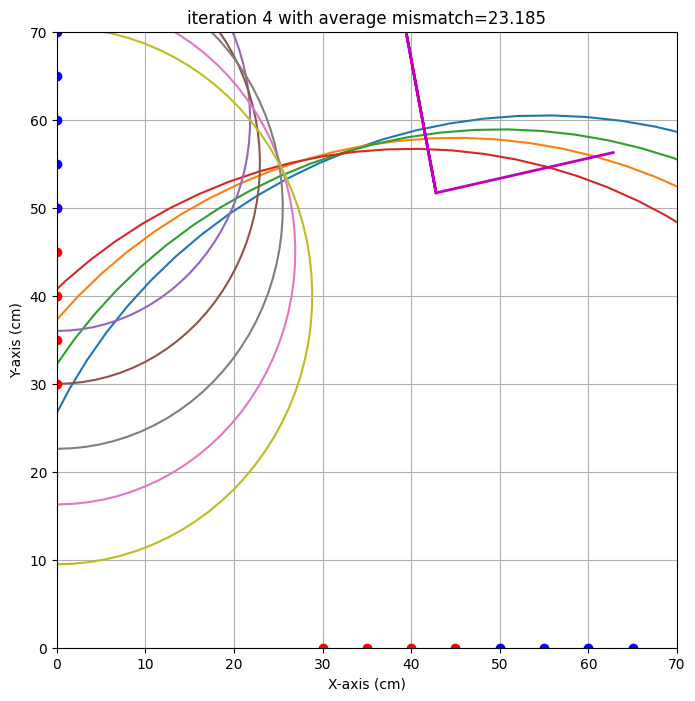

end iteration 4 with average mismatch=23.185


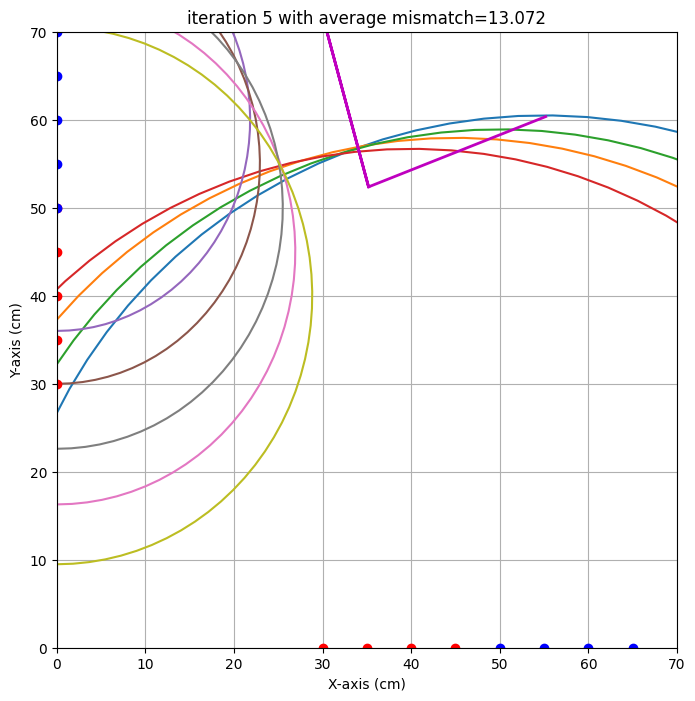

end iteration 5 with average mismatch=13.072


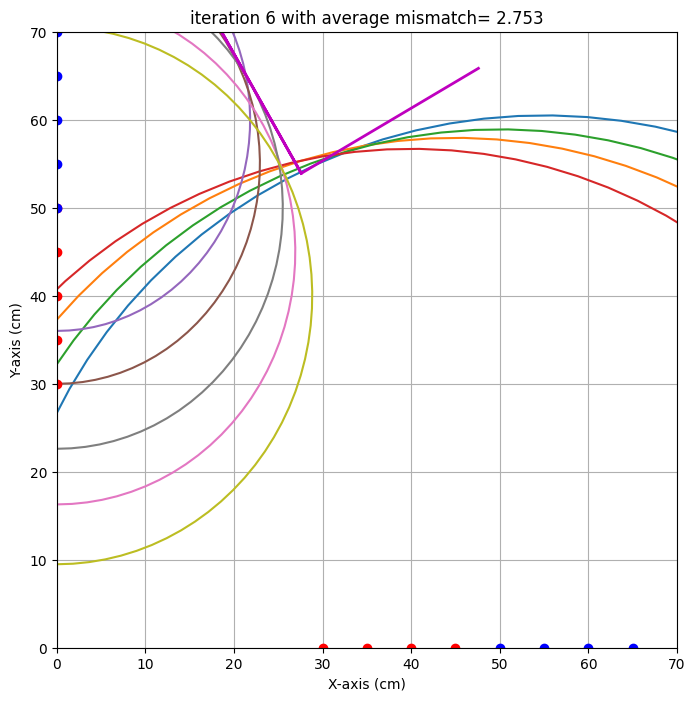

end iteration 6 with average mismatch= 2.753


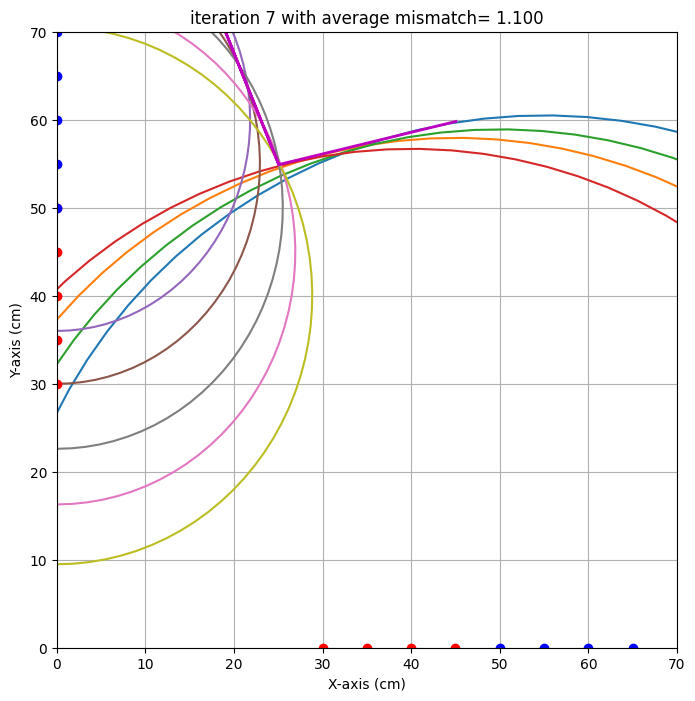

end iteration 7 with average mismatch= 1.100
end iteration 8 with average mismatch= 1.020
end iteration 9 with average mismatch= 0.970
end iteration 10 with average mismatch= 0.897
end iteration 11 with average mismatch= 0.897
end iteration 12 with average mismatch= 0.888
end iteration 13 with average mismatch= 0.885
end iteration 14 with average mismatch= 0.877
end iteration 15 with average mismatch= 0.856
end iteration 16 with average mismatch= 0.845
end iteration 17 with average mismatch= 0.845
end iteration 18 with average mismatch= 0.845
end iteration 19 with average mismatch= 0.845
end iteration 20 with average mismatch= 0.845
end iteration 21 with average mismatch= 0.845
end iteration 22 with average mismatch= 0.845
end iteration 23 with average mismatch= 0.845
end iteration 24 with average mismatch= 0.836
end iteration 25 with average mismatch= 0.828
end iteration 26 with average mismatch= 0.819
end iteration 27 with average mismatch= 0.819
end iteration 28 with average mismatc

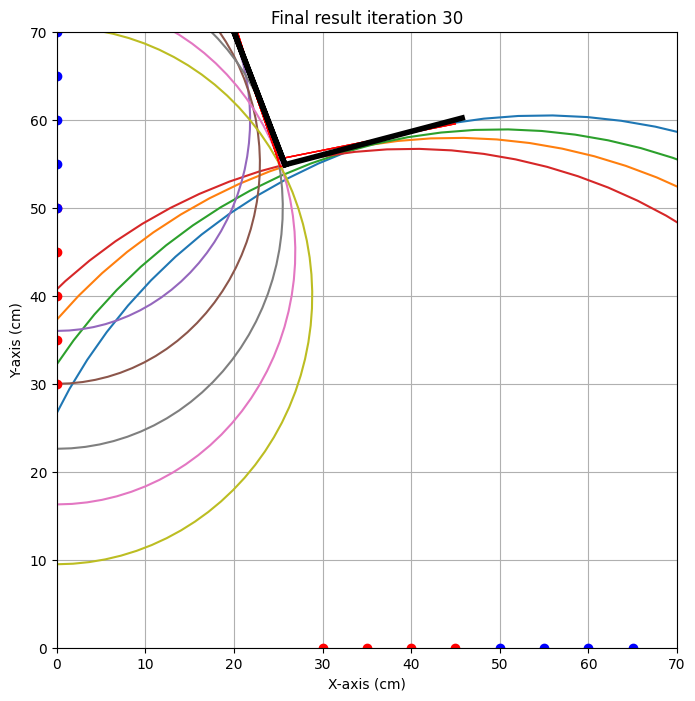

{'alpha': np.float64(14.863982692638997), 'alpha_eps': np.float64(3.494190606427086), 'beta': np.float64(-20.907982221030636), 'beta_eps': np.float64(3.433953087162152), 'x0': np.float64(25.75336448111167), 'x0_eps': np.float64(0.7763314445969236), 'y0': np.float64(54.88726809010347), 'y0_eps': np.float64(0.6290541895546866)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 25.8 cm met een standaardafwijking van 0.8 cm 
y0 target is : 49.0. Gevonden waarde: 54.9 cm met een standaardafwijking van 0.6 cm 
alpha target is : 22.0. Gevonden waarde: 14.9 graden met een standaardafwijking van 3.5 graad 
beta target is : -23.0. Gevonden waarde: -20.9 graden met een standaardafwijking van 3.4 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':25,  # zelf aanvullen,
                    'y0':49,  # zelf aanvullen,
                    'alpha' :22,  # zelf aanvullen,
                    'beta' :-23  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                #[20,0,40,0,x],
                #[50,0,70,0,128.21],
                [45,0,65,0,122.63],
                [35,0,55,0,117.6],
                [40,0,60,0,119.5],
                [30,0,50,0,115.14],
                #[0,20,0,40,x],
                [0,50,0,70,48],
                [0,45,0,65,50.02],
                [0,35,0,55,57.43],
                [0,40,0,60,54.79],
                [0,30,0,50,61.03],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algorBob.jpeg "Het idee van Bob")

Figuur: ![Alt](algorAdam1.jpeg "Het idee van Adam foto 1")

Figuur: ![Alt](algorAdam2.jpeg "Het idee van Adam foto 2")

Figuur: ![Alt](algorDexter.jpeg "Het idee van Dexter")

Figuur: ![Alt](algorAdam1.jpeg "Het idee van Adam foto 1")